# Forecasting de Ventas — VIVO Balanced Bites

> **Objetivo:** Pronosticar las ventas semanales de los productos críticos del restaurante universitario VIVO Balanced Bites (sede Principal — Universidad de los Andes), usando datos reales de facturación desde agosto 2024.
>
> **Pipeline:**
> 1. Carga y limpieza de datos de ventas y compras
> 2. Análisis Exploratorio (EDA) + Segmentación de productos (Matriz BCG + Pareto ABC)
> 3. Identificación de productos críticos
> 4. Modelado con **Prophet** (series de tiempo + calendario académico)
> 5. Modelado con **XGBoost** (short-term, basado en lags)
> 6. Modelo **Híbrido** Prophet + XGBoost


## 0. Setup y librerías

Se importan todas las librerías necesarias para el proyecto:
- **pandas / numpy**: manejo y transformación de datos
- **matplotlib / seaborn / plotly**: visualización estática e interactiva
- **sklearn**: métricas de evaluación y preprocesamiento
- **pathlib**: manejo de rutas de archivos multiplataforma


In [1]:
# ── Manejo de datos ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
# ── Visualización ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# ── Machine Learning ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

# ── Utilidades ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')  # Suprimir advertencias de versiones de librerías


## 1. Carga de datos

Se cargan dos tipos de archivos Excel desde OneDrive:

1. **Archivos de productos** (`/Productos/Mes-Año.xlsx`): reportes mensuales con el detalle de cada transacción por producto (ventas y compras). Se leen a partir de la fila 8 (header=7) porque el formato de Siigo tiene encabezados de informe antes de la tabla.

2. **Archivos de factura por lugar** (`/Facturas_lugar/Lugar-Año.xlsx`): facturas agrupadas por punto de venta (Principal y Café Principal). Se leen a partir de la fila 7 (header=6).

Los archivos se almacenan en diccionarios con clave `"Mes-Año"` y `"Lugar-Año"` respectivamente.


In [2]:
from pathlib import Path
import pandas as pd

carpeta = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Productos")
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
años = ["2024", "2025", "2026"]

productos = {}
for año in años:
    for mes in meses:
        archivo = f"{mes}-{año}.xlsx"
        ruta = carpeta / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=7)
            productos[f"{mes}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

carpeta_2 = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Facturas_lugar")
lugares = ["CP", "Principal"]

factura_lugar = {}
for año in años:
    for lugar in lugares:
        archivo = f"{lugar}-{año}.xlsx"
        ruta = carpeta_2 / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=6)
            factura_lugar[f"{lugar}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

print("Productos cargados:", list(productos.keys()))
print("Facturas lugar cargadas:", list(factura_lugar.keys()))


No encontrado: Enero-2024.xlsx
No encontrado: Febrero-2024.xlsx
No encontrado: Marzo-2024.xlsx
No encontrado: Abril-2024.xlsx
No encontrado: Mayo-2024.xlsx
No encontrado: Junio-2024.xlsx
No encontrado: Julio-2024.xlsx
No encontrado: Abril-2026.xlsx
No encontrado: Mayo-2026.xlsx
No encontrado: Junio-2026.xlsx
No encontrado: Julio-2026.xlsx
No encontrado: Agosto-2026.xlsx
No encontrado: Septiembre-2026.xlsx
No encontrado: Octubre-2026.xlsx
No encontrado: Noviembre-2026.xlsx
No encontrado: Diciembre-2026.xlsx
No encontrado: CP-2024.xlsx
No encontrado: Principal-2024.xlsx
No encontrado: CP-2026.xlsx
No encontrado: Principal-2026.xlsx
Productos cargados: ['Agosto-2024', 'Septiembre-2024', 'Octubre-2024', 'Noviembre-2024', 'Diciembre-2024', 'Enero-2025', 'Febrero-2025', 'Marzo-2025', 'Abril-2025', 'Mayo-2025', 'Junio-2025', 'Julio-2025', 'Agosto-2025', 'Septiembre-2025', 'Octubre-2025', 'Noviembre-2025', 'Diciembre-2025', 'Enero-2026', 'Febrero-2026', 'Marzo-2026']
Facturas lugar cargadas: [

## 2. Análisis Exploratorio (EDA)

En esta sección se:
1. Verifica el rango de fechas de cada archivo mensual cargado
2. Se unifican todos los meses en un único DataFrame (`df_total`)
3. Se unen los datos de ventas por establecimiento (`df_place`)
4. Se separan las **facturas de venta** de las **facturas de compra**
5. Se limpian y homologan las columnas para tener un dataset de `ventas` listo para analizar


In [3]:
col_fecha = "Fecha elaboración"

# Verificar rango de fechas de cada archivo cargado
# Esto ayuda a detectar archivos con datos corruptos o fuera del período esperado
for mes, df in productos.items():
    df[col_fecha] = pd.to_datetime(df[col_fecha], dayfirst=True, errors="coerce")
    inicio = df[col_fecha].min()
    fin = df[col_fecha].max()
    print(f"{mes}: {inicio.date()} → {fin.date()}")


Agosto-2024: 2024-08-03 → 2024-08-30
Septiembre-2024: 2024-09-06 → 2024-09-24
Octubre-2024: 2024-10-04 → 2024-10-21
Noviembre-2024: 2024-11-25 → 2024-11-25
Diciembre-2024: 2024-12-04 → 2024-12-12
Enero-2025: 2025-01-08 → 2025-01-31
Febrero-2025: 2025-02-01 → 2025-02-28
Marzo-2025: 2025-03-02 → 2025-03-31
Abril-2025: 2025-04-01 → 2025-04-30
Mayo-2025: 2025-05-01 → 2025-05-31
Junio-2025: 2025-06-03 → 2025-06-30
Julio-2025: 2025-07-01 → 2025-07-31
Agosto-2025: 2025-08-04 → 2025-08-31
Septiembre-2025: 2025-09-01 → 2025-09-30
Octubre-2025: 2025-10-01 → 2025-10-31
Noviembre-2025: 2025-11-04 → 2025-11-30
Diciembre-2025: 2025-12-01 → 2025-12-31
Enero-2026: 2026-01-07 → 2026-01-31
Febrero-2026: 2026-02-02 → 2026-02-28
Marzo-2026: 2026-03-02 → 2026-03-27


### Unificar todos los meses en un solo DataFrame

Se concatenan todos los DataFrames mensuales (uno por cada archivo `Mes-Año.xlsx`) en un único DataFrame `df_total`. Se usa `ignore_index=True` para reiniciar el índice y evitar duplicados.


In [4]:
df_total = pd.concat(productos.values(), ignore_index=True)


### Unificar ventas por lugar (establecimiento)

Se combinan los DataFrames de CP (Café Principal) y Principal en un único `df_place`, añadiendo una columna `"Lugar"` que identifica el establecimiento de cada factura. Esto permite filtrar y comparar ventas por punto de venta.


In [5]:
# Extraer los DataFrames de cada establecimiento
CP_df = factura_lugar["CP-2025"]
Principal_df = factura_lugar["Principal-2025"]

# Agregar columna de identificación antes de unir
# (necesario para saber de qué local proviene cada fila después del concat)
CP_df["Lugar"] = "CP"
Principal_df["Lugar"] = "Principal"

# Unificar en un solo DataFrame con todos los establecimientos
df_place = pd.concat([CP_df, Principal_df], ignore_index=True)


### Comparar columnas entre los dos DataFrames

Se identifican qué columnas existen solo en `df_total` (por producto), solo en `df_place` (por lugar) y cuáles son comunes. Esto ayuda a entender qué información aporta cada fuente y cómo unirlas si es necesario.


In [6]:
col1 = set(df_total.columns)   # columnas del df por producto
col2 = set(df_place.columns)   # columnas del df por lugar

# Columnas exclusivas de cada fuente y columnas comunes
print("Solo en df_total (por producto):", col1 - col2)
print("Solo en df_place (por lugar):", col2 - col1)
print("En ambos (posibles llaves de join):", col2 & col1)


Solo en df_total (por producto): {'Sucursal', 'Fecha vencimiento', 'Código', 'Observaciones', 'Cargo en totales', 'Identificación', 'Tasa de cambio', 'Impuesto cargo', 'Referencia fábrica', 'Centro costo', 'Nombre vendedor', 'Fecha modificación', 'Tipo transacción', 'Fecha creación', 'Identificación Vendedor', 'Consecutivo', 'Cantidad', 'Base AIU', 'Nombre tercero', 'Forma pago', 'Factura proveedor', 'Tipo clasificación', 'Fecha elaboración', 'Bodega', 'Descuento en totales', 'Base retención (ICA/IVA)', 'Correo electrónico', 'Tipo de registro', 'Valor unitario', 'Valor Impuesto Cargo', 'Número comprobante', 'Impuesto Cargo 2', 'Impuesto retención', 'Nombre', 'Nombre contacto', 'Valor Impuesto Retención', 'Valor desc.', 'Valor Impuesto Cargo 2'}
Solo en df_place (por lugar): {'Tipo de comprobante', 'Nro. de identificación', 'Otros', 'Tarjetas', 'Pagos en línea', 'Lugar', 'Estado', 'Crédito', 'Nro. de comprobante', 'Vendedor', 'Fecha y hora', 'Efectivo', 'Turno', 'Cliente'}
En ambos (pos

### Separar ventas y compras, y seleccionar columnas relevantes

Los archivos de Siigo mezclan facturas de **venta** y de **compra** en la misma hoja. Aquí se separan:
- `df_ventas_producto`: solo filas con `"Tipo transacción" == "Factura de venta"`
- `df_compras_producto`: solo filas con `"Tipo transacción" == "Factura de compra"`

Adicionalmente, se asigna el **establecimiento** según el número de comprobante:
- `FV-1` → Principal | `FV-4` → CP | `FV-2/FV-3` → Eventos


In [7]:
#Ventas
df_ventas_producto=df_total[df_total["Tipo transacción"]=="Factura de venta"]
df_ventas_producto = df_ventas_producto.reset_index(drop=True)

variables_iniciales=["Consecutivo","Fecha creación","Tipo de registro","Tipo clasificación","Código","Nombre","Nombre vendedor",\
                     "Cantidad","Valor unitario","Valor Impuesto Cargo","Total","Forma pago","Número comprobante"]
df_ventas_producto_filtrado=df_ventas_producto[variables_iniciales]

df_ventas_producto_filtrado['Establecimiento'] = df_ventas_producto_filtrado['Número comprobante'].map({'FV-1': 'Principal',"FV-2":"Eventos","FV-3":"Eventos",'FV-4': 'CP'})

#Compras
df_compras_producto=df_total[df_total["Tipo transacción"]=="Factura de compra"]
variables_compras=["Consecutivo","Factura proveedor","Identificación","Nombre tercero","Fecha creación","Fecha modificación","Fecha elaboración","Nombre contacto"\
    ,"Tipo de registro","Tipo clasificación","Código","Nombre","Cantidad","Valor unitario","Total","Forma pago","Fecha vencimiento"]

df_compras_producto_filtrado=df_compras_producto[variables_compras]


### Convertir columnas de fecha a tipo `datetime`

Las fechas vienen en formato de texto `'DD/MM/YYYY'` desde Excel. Se convierten a tipo `datetime` de pandas para poder hacer operaciones temporales (agrupar por mes, semana, etc.).


In [8]:

df_ventas_producto_filtrado['Fecha creación'] = pd.to_datetime(df_ventas_producto_filtrado
                                                               ['Fecha creación'], format='%d/%m/%Y')

fechas = ["Fecha creación", "Fecha modificación", "Fecha elaboración", "Fecha vencimiento"]
df_compras_producto_filtrado[fechas] = df_compras_producto_filtrado[fechas].apply(
    pd.to_datetime, format='%d/%m/%Y'
)


### Propagar la forma de pago y limpiar filas vacías

En Siigo, la forma de pago (efectivo, tarjeta, etc.) aparece solo en la **primera fila** de cada factura. Las filas siguientes (que corresponden a cada ítem de la factura) tienen ese campo vacío.

- `.bfill()` propaga el valor hacia abajo para que cada ítem tenga su forma de pago
- `.dropna(subset=["Código"])` elimina las filas que solo eran encabezados de pago y no tienen producto asociado


In [9]:
#Poner el tipo de transacción de cda fila 
df_ventas_producto_filtrado["Forma pago"]=df_ventas_producto_filtrado["Forma pago"].bfill()
df_compras_producto_filtrado["Forma pago"]=df_compras_producto_filtrado["Forma pago"].bfill()
#Eliminar las filas que hacian referencia al metodo de pago
df_ventas_producto_filtrado.dropna(subset=["Código"],inplace=True)
df_compras_producto_filtrado.dropna(subset=["Código"],inplace=True)


### Eliminar columnas innecesarias

Se eliminan `"Tipo de registro"` y `"Tipo clasificación"` porque son columnas internas de Siigo que no aportan información útil para el análisis de ventas.


In [10]:
df_ventas_producto_filtrado.drop(columns=["Tipo de registro","Tipo clasificación"],inplace=True)


### Dataset final de ventas

Se renombra `"Fecha creación"` a `"Fecha"` para simplificar el acceso. El DataFrame `ventas` queda con las columnas clave: **Fecha, Nombre del producto, Cantidad, Total, Establecimiento, Forma de pago** y **Número de comprobante**.


In [11]:
# Alias más corto para facilitar el uso en el resto del notebook
ventas = df_ventas_producto_filtrado

# Renombrar "Fecha creación" → "Fecha" para simplificar acceso
ventas.rename(columns={"Fecha creación": "Fecha"}, inplace=True)

ventas  # Mostrar el DataFrame final de ventas


,Consecutivo,Fecha,Código,Nombre,Nombre vendedor,Cantidad,Valor unitario,Valor Impuesto Cargo,Total,Forma pago,Número comprobante,Establecimiento
0,401.0,2024-08-30,11,Sándwich o pockets (Mini chef),Tatiana Perez,1.0,12962.96,1037.04,14000.0,Tarjeta Débito,FV-1,Principal
1,401.0,2024-08-30,28,Ensalada Pollo miel mostaza Mediana,Tatiana Perez,1.0,18518.52,1481.48,20000.0,Tarjeta Débito,FV-1,Principal
2,401.0,2024-08-30,38,Arma tu plato mediano (18k),Tatiana Perez,1.0,20370.37,1629.63,22000.0,Tarjeta Débito,FV-1,Principal
3,401.0,2024-08-30,66,Pancakes chocolate,Tatiana Perez,1.0,8888.89,711.11,9600.0,Tarjeta Débito,FV-1,Principal
5,402.0,2024-08-30,B0002,Agua cristal,Tatiana Perez,1.0,2777.78,222.22,3000.0,Efectivo,FV-1,Principal
...,...,...,...,...,...,...,...,...,...,...,...,...
34767,990.0,2026-03-02,56543553,Empanada,Juan Jose Yara Vallejo,2.0,5000.00,0.00,10000.0,Efectivo,FV-4,CP
34769,991.0,2026-03-02,26,Ensalada Chefsito Mediana,Juan Jose Yara Vallejo,1.0,21296.30,1703.70,23000.0,Tarjeta Débito,FV-4,CP
34771,992.0,2026-03-02,53,Hatsu blanco 400ml,Juan Jose Yara Vallejo,1.0,7407.41,592.59,8000.0,Tarjeta Débito,FV-4,CP
34773,993.0,2026-03-02,79,Americano Mediano,Juan Jose Yara Vallejo,1.0,5000.00,0.00,5000.0,Efectivo,FV-4,CP


### Cargar datos de compras

Las compras se cargan desde un CSV pre-procesado (`compras.csv`) que ya tiene el formato correcto con columna `Periodo` y `Total`. Este archivo se generó previamente a partir de los datos de Siigo.


In [12]:
compras=compras = pd.read_csv('compras.csv')


### Agregar columna de período mensual

Se agrega la columna `"Periodo"` con formato `YYYY-MM` (tipo `Period`) para agrupar las ventas por mes. Esto permite hacer resúmenes mensuales y gráficos de tendencia en el tiempo.


In [13]:
ventas["Periodo"] = pd.to_datetime(ventas["Fecha"]).dt.to_period("M")


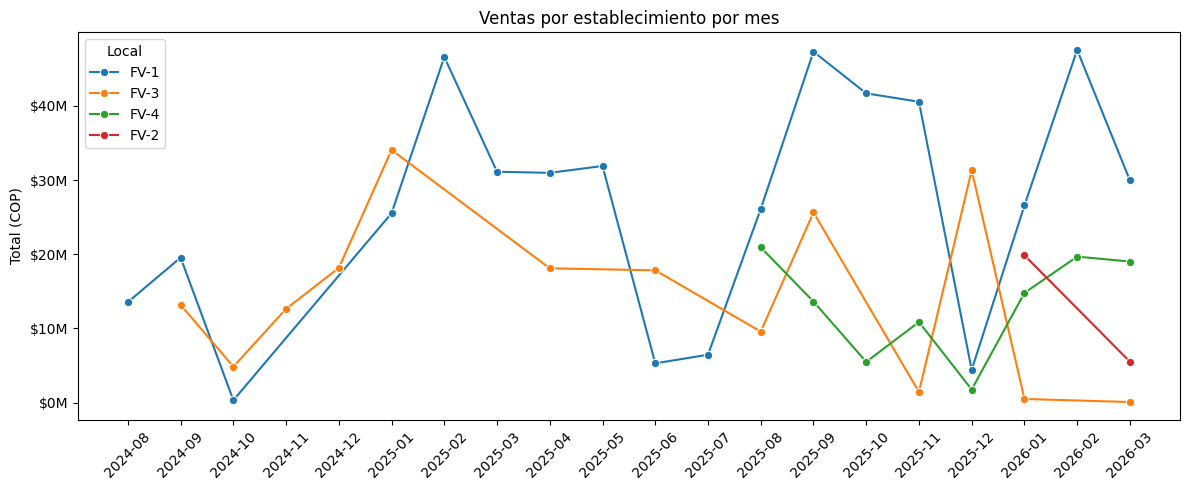

In [14]:

resumen = (
    ventas
    .groupby(["Periodo", "Número comprobante"])["Total"]
    .sum()
    .reset_index()
)

resumen["Periodo"] = resumen["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=resumen,
    x="Periodo",
    y="Total",
    hue="Número comprobante",
    marker="o"              # ← agrega puntos en cada mes
)
plt.xticks(rotation=45)
plt.title("Ventas por establecimiento por mes")
plt.ylabel("Total (COP)")
plt.xlabel("")
plt.legend(title="Local")  # ← título más claro en la leyenda

# Formato en millones en el eje Y
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()


### Ventas por establecimiento y mes (gráfico de líneas)

Se calcula el total de ventas agrupando por `Periodo` y `Número comprobante` (que identifica el establecimiento). El gráfico de líneas muestra la evolución mensual de cada punto de venta por separado, permitiendo detectar cuál aporta más y si hay patrones estacionales diferenciados.


In [15]:
import pandas as pd
import plotly.express as px

# 1. Resumen de ventas
resumen_mes = (
    ventas
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)

# Convertir a string es vital para que no lo trate como fecha continua
resumen_mes["Periodo"] = resumen_mes["Periodo"].astype(str)

# 2. Gráfico interactivo
fig = px.bar(
    resumen_mes, 
    x="Periodo", 
    y="Total",
    title="Análisis de Ventas por Periodo",
    labels={"Total": "Monto ($)", "Periodo": "Mes"},
    text_auto='.2s', 
    color_discrete_sequence=["steelblue"]
)

# 3. Personalización estética (Aquí forzamos que aparezcan todos los meses con datos)
fig.update_layout(
    xaxis_tickangle=-45,
    # ESTA LÍNEA ES LA QUE ELIMINA LOS HUECOS VACÍOS COMO DICIEMBRE:
    xaxis_type='category', 
    yaxis_tickformat="$.2s", # Cambiado a .2s para que el eje diga $80M en lugar de $80,000,000
    hovermode="x unified",
    template="plotly_white"
)

# 4. Mostrar el gráfico
fig.show()


### Tendencia general de ventas (gráfico interactivo)

Gráfico de barras interactivo con Plotly que muestra el **total de ventas consolidado por mes** (todos los establecimientos juntos). Se usa `xaxis_type='category'` para evitar que Plotly muestre meses sin datos como huecos en el eje X.


In [16]:
import plotly.express as px

# 1. Preparación (Asegúrate de convertir el periodo a texto para evitar los huecos)
resumen_compras_mes = (
    compras
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)
resumen_compras_mes["Periodo"] = resumen_compras_mes["Periodo"].astype(str)

# 2. Gráfico
fig = px.bar(
    resumen_compras_mes, 
    x="Periodo", 
    y="Total",
    title="Total Compras por Periodo",
    color_discrete_sequence=["#CD5C5C"] # Rojo similar al de tu imagen
)

# 3. El truco para quitar los huecos y poner el formato $18M
fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    # ESTA LÍNEA QUITA LOS HUECOS:
    xaxis_type='category', 
    # ESTA LÍNEA PONE EL FORMATO $18M:
    yaxis_tickformat="$.2s", 
    hovermode="x unified"
)

# Personalizar el texto al pasar el mouse
fig.update_traces(
    hovertemplate="<b>Periodo:</b> %{x}<br><b>Total:</b> $%{y:,.0f}"
)

fig.show()


### Tendencia de compras (gráfico interactivo)

Mismo análisis pero para las **compras** (costo de insumos). Comparar este gráfico con el de ventas permite identificar si el margen se mantiene estable o hay meses donde el costo sube desproporcionalmente.


In [17]:
ventas_compras = resumen_mes.merge(
    resumen_compras_mes, 
    on="Periodo", 
    how="outer",
    suffixes=("_ventas", "_compras")
)

ventas_compras = ventas_compras.fillna(0)
ventas_compras["Utilidad"] = ventas_compras["Total_ventas"] - ventas_compras["Total_compras"]
ventas_compras = ventas_compras.sort_values("Periodo").reset_index(drop=True)

print(ventas_compras[["Periodo", "Total_ventas", "Total_compras", "Utilidad"]])


    Periodo  Total_ventas  Total_compras     Utilidad
0   2024-08   13552500.00     17591988.0  -4039488.00
1   2024-09   32727310.00            0.0  32727310.00
2   2024-10    5174300.00            0.0   5174300.00
3   2024-11   12644600.00            0.0  12644600.00
4   2024-12   18159161.00            0.0  18159161.00
5   2025-01   59576997.17      4249653.0  55327344.17
6   2025-02   46580484.50      3089645.0  43490839.50
7   2025-03   31114572.00      3692100.0  27422472.00
8   2025-04   49071040.40      4949213.0  44121827.40
9   2025-05   31888620.00      5764664.0  26123956.00
10  2025-06   23134199.26      2863814.0  20270385.26
11  2025-07    6460500.00      6150784.0    309716.00
12  2025-08   56603715.00      5242819.0  51360896.00
13  2025-09   86547085.00      9624248.0  76922837.00
14  2025-10   47174155.00      4496786.0  42677369.00
15  2025-11   52863172.00      5109383.0  47753789.00
16  2025-12   37505122.90      2227879.0  35277243.90
17  2026-01   61709036.00   

### Calcular utilidad bruta por mes

Se hace un `merge` entre ventas y compras por período, y se calcula la **utilidad bruta** = Ventas - Compras. Los valores negativos indican meses donde los costos superaron los ingresos (p.ej., meses de cierre o de compras anticipadas).

> ⚠️ Esta es una utilidad bruta simplificada. No incluye costos fijos (arriendo, nómina, servicios).


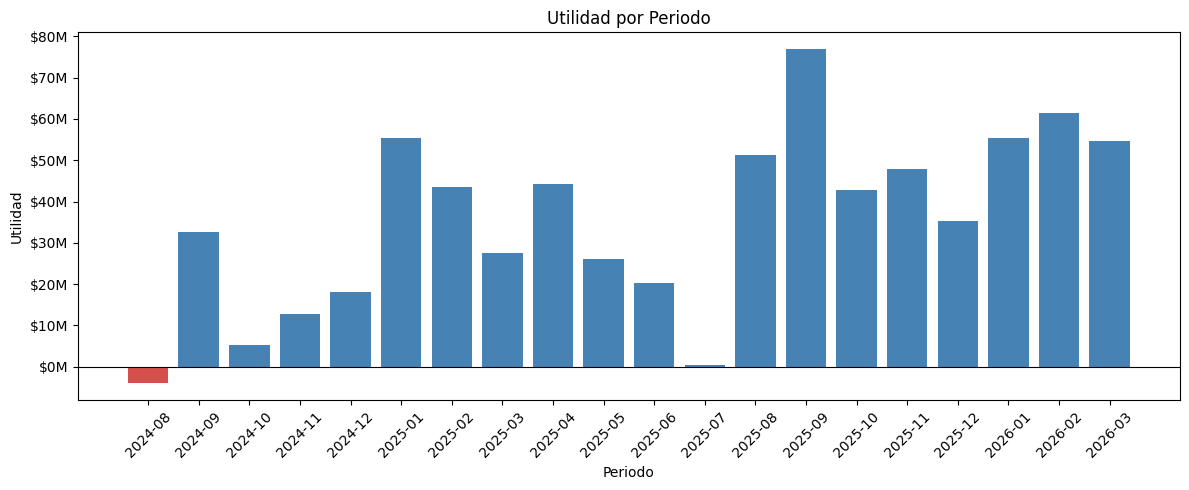

In [18]:
plt.figure(figsize=(12, 5))
plt.bar(ventas_compras["Periodo"], ventas_compras["Utilidad"], 
        color=["#d5504b" if x < 0 else "steelblue" for x in ventas_compras["Utilidad"]])
plt.title("Utilidad por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Utilidad")
plt.xticks(rotation=45)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


In [19]:
# Filtrar solo el establecimiento Principal desde 2024
# (se excluye CP y Eventos para analizar el local principal de forma aislada)
ventas_p = (
    ventas[
        (ventas["Establecimiento"] == "Principal") &
        (ventas["Fecha"] >= "2024-01-01")
    ]
    .sort_values("Fecha", ascending=True)
    .reset_index()
)




### Limpiar nombres de cada producto

In [20]:

def limpiar_nombre_final(text):
    if pd.isna(text): return text
    
    # 1. Definir qué queremos ELIMINAR (Tamaños, pesos, precios, paréntesis)
    # Eliminamos: (21k), (18k), 9oz, 14oz, Mediana, Grande, Mediano, Veggie
    patrones_a_remover = [
        r'\(.*\)',          # Todo lo que esté entre paréntesis
        r'\d+k',            # Precios tipo 18k, 21k
        r'\d+oz',           # Pesos tipo 9oz, 14oz
        r'Mediana', r'Mediano', r'Grande', r'Veggie', # Palabras de tamaño
        r'400ml', r'600ml', r'250ml', r'450ml'         # Volúmenes de bebidas
    ]
    
    temp_name = text
    for patron in patrones_a_remover:
        temp_name = re.sub(patron, '', temp_name, flags=re.IGNORECASE)
    
    # 2. Limpieza de espacios y estandarización
    temp_name = " ".join(temp_name.split()).strip()
    
    # 3. Mapeo de excepciones (Casos que Regex no limpia solo)
    mapeo_especifico = {
        'Hatsu amarillo': 'Hatsu Amarillo',
        'Chocolate caliente': 'Chocolate Caliente',
        'Pastel de pollo': 'Pastel de Pollo',
        'Agua cristal': 'Agua sin Gas',
        'Agua sin gas cristal': 'Agua sin Gas',
        'Agua con gas cristal': 'Agua con Gas',
        'Soda rosada': 'Soda Hatsu Rosada',
        'Parfaits': 'Parfait Frutos Rojos',
        'Parfaits frutos rojos': 'Parfait Frutos Rojos'
    }
    
    # Retornar el nombre mapeado o el limpio con la primera letra en mayúscula
    nombre_limpio = mapeo_especifico.get(temp_name, temp_name)
    return nombre_limpio.capitalize() if len(nombre_limpio) > 0 else text

# --- APLICACIÓN EN TU DATAFRAME ---

# Crear la columna de apoyo 'name'
ventas_p['name'] = ventas_p['Nombre'].apply(limpiar_nombre_final)

# Reemplazar la columna Original por la limpia
ventas_p['Nombre'] = ventas_p['name']

# Eliminar la columna temporal 'name' para que el DF quede impecable
ventas_p = ventas_p.drop(columns=['name'])

# Visualizar el resultado
ventas_p.head(20)


,index,Consecutivo,Fecha,Código,Nombre,Nombre vendedor,Cantidad,Valor unitario,Valor Impuesto Cargo,Total,Forma pago,Número comprobante,Establecimiento,Periodo
0,1143,10.0,2024-08-05,17,Bowl colombianito,Juan Jose Yara Vallejo,1.0,19166.67,1533.33,20700.0,Efectivo,FV-1,Principal,2024-08
1,1141,1.0,2024-08-05,18,Bowl pollo tostada,Tatiana Perez,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
2,1145,11.0,2024-08-05,17,Bowl colombianito,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
3,1146,11.0,2024-08-05,19,Bowl pollo tostada,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
4,1148,12.0,2024-08-05,17,Bowl colombianito,Juan Jose Yara Vallejo,1.0,21296.30,1703.70,23000.0,Tarjeta Débito,FV-1,Principal,2024-08
5,1151,13.0,2024-08-05,24,Ensalada kale cesar,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
6,1152,13.0,2024-08-05,37,Ensalada italianísima,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Efectivo,FV-1,Principal,2024-08
7,1154,2.0,2024-08-05,26,Ensalada chefsito,Juan Jose Yara Vallejo,1.0,18518.52,1481.48,20000.0,Tarjeta Débito,FV-1,Principal,2024-08
8,1149,12.0,2024-08-05,39,Arma tu plato,Juan Jose Yara Vallejo,1.0,19444.44,1555.56,21000.0,Tarjeta Débito,FV-1,Principal,2024-08
9,1158,4.0,2024-08-05,39,Arma tu plato,Juan Jose Yara Vallejo,1.0,22222.22,1777.78,24000.0,Tarjeta Débito,FV-1,Principal,2024-08


### seleccionar solo las columnas necesarias

In [21]:
# Seleccionar solo las columnas necesarias para el análisis de productos
dataset_p = ventas_p[["Fecha", "Nombre", "Cantidad", "Total"]]


## 2.1 Segmentación de productos — Matriz BCG

Se analiza el catálogo de productos del **establecimiento Principal** (desde enero 2024) para identificar cuáles son los más importantes para el negocio.

Para cada producto se calcula:
- **transacciones**: número de veces que fue vendido
- **cantidad_total**: unidades totales vendidas
- **precio_promedio**: precio por unidad
- **Plata generada**: ingresos totales

Luego se clasifica cada producto en un cuadrante de la **Matriz BCG adaptada**:
| Cuadrante | Criterio |
|---|---|
| **ESTRELLA** | Alto volumen Y alta plata generada |
| **PREMIUM** | Bajo volumen PERO alta plata (producto caro) |
| **GANCHO** | Alto volumen PERO baja plata (producto barato/de conveniencia) |
| **BAJO DESEMPEÑO** | Bajo volumen Y baja plata |

Los cortes se hacen en la **mediana** de cada métrica.


In [22]:
# Calcular métricas de desempeño por producto
# Se usa groupby + apply para calcular estadísticas de cada producto en una sola pasada
info_productos = dataset_p.groupby("Nombre").apply(lambda x: pd.Series({
    "transacciones":    x["Nombre"].count(),              # nº de veces que se vendió
    "cantidad_total":   x["Cantidad"].sum(),              # unidades totales vendidas
    "precio_promedio":  x["Total"].sum() / x["Cantidad"].sum(),  # precio promedio ponderado
    "Plata generada":   x["Total"].sum()                  # ingresos totales
})).sort_values("transacciones", ascending=False)


In [23]:
# Definimos los puntos de corte
corte_x = info_productos["cantidad_total"].median()
corte_y = info_productos["Plata generada"].median()

# Función para asignar el color/categoría
def clasificar(row):
    if row["cantidad_total"] >= corte_x and row["Plata generada"] >= corte_y:
        return "ESTRELLA (Alto Vol / Alto $)"
    elif row["cantidad_total"] < corte_x and row["Plata generada"] >= corte_y:
        return "PREMIUM (Bajo Vol / Alto $)"
    elif row["cantidad_total"] >= corte_x and row["Plata generada"] < corte_y:
        return "GANCHO (Alto Vol / Bajo $)"
    else:
        return "BAJO DESEMPEÑO"

# Aplicamos la lógica al DataFrame
info_productos["Categoria_Matriz"] = info_productos.apply(clasificar, axis=1)

# ── Conteo por cuadrante ──────────────────────────────────────────────────────
conteos = info_productos["Categoria_Matriz"].value_counts()
n_estrella = conteos.get("ESTRELLA (Alto Vol / Alto $)", 0)
n_premium  = conteos.get("PREMIUM (Bajo Vol / Alto $)", 0)
n_gancho   = conteos.get("GANCHO (Alto Vol / Bajo $)", 0)
n_bajo     = conteos.get("BAJO DESEMPEÑO", 0)

import plotly.express as px

fig = px.scatter(
    info_productos.reset_index(), 
    x="cantidad_total", 
    y="Plata generada",
    color="Categoria_Matriz",
    color_discrete_map={
        "ESTRELLA (Alto Vol / Alto $)": "#2ecc71",
        "PREMIUM (Bajo Vol / Alto $)": "#3498db",
        "GANCHO (Alto Vol / Bajo $)": "#f1c40f",
        "BAJO DESEMPEÑO": "#e74c3c"
    },
    hover_name="Nombre",
    log_x=True, 
    log_y=True,
    hover_data=["precio_promedio", "transacciones"],
    title="Dashboard de Estrategia de Productos",
    template="plotly_white"
)

fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='white')))
fig.add_vline(x=corte_x, line_dash="dot", line_color="gray", opacity=0.5)
fig.add_hline(y=corte_y, line_dash="dot", line_color="gray", opacity=0.5)

# ── Anotaciones en las 4 esquinas ─────────────────────────────────────────────
anotaciones = [
    dict(x=0.99, y=0.99, text=f"<b> {n_estrella} productos</b>",
         font=dict(color="#27ae60", size=12),
         xanchor="right", yanchor="top"),
    dict(x=0.01, y=0.99, text=f"<b> {n_premium} productos</b>",
         font=dict(color="#2980b9", size=12),
         xanchor="left", yanchor="top"),
    dict(x=0.99, y=0.01, text=f"<b> {n_gancho} productos</b>",
         font=dict(color="#d4ac0d", size=12),
         xanchor="right", yanchor="bottom"),
    dict(x=0.01, y=0.01, text=f"<b> {n_bajo} productos</b>",
         font=dict(color="#c0392b", size=12),
         xanchor="left", yanchor="bottom"),
]

for a in anotaciones:
    fig.add_annotation(
        x=a["x"], y=a["y"],
        text=a["text"],
        showarrow=False,
        font=a["font"],
        xref="paper", yref="paper",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="lightgray",
        borderwidth=1,
        borderpad=6,
        xanchor=a["xanchor"],
        yanchor=a["yanchor"],
    )

fig.update_layout(
    legend_title_text='Categoría de Negocio',
    font=dict(family="Verdana", size=12)
)

fig.show()


In [24]:
info_productos=info_productos.reset_index()


In [25]:
ventas_p["Nombre"].unique()


array(['Bowl colombianito', 'Bowl pollo tostada', 'Ensalada kale cesar',
       'Ensalada italianísima', 'Ensalada chefsito', 'Arma tu plato',
       'Bowl lomo alto', 'Sándwich o pockets', 'Parfait frutos rojos',
       'Ensalada pollo pesto', 'Agua sin gas', 'Bowl pasta buona',
       'Hatsu amarillo', 'Ensalada pollo miel mostaza', 'Hatsu blanco',
       'Soda hatsu rosada', 'Sándwich felix carne', 'Sándwich becha',
       'Sándwich felix pollo', 'Leche de almendras', 'Pancakes chocolate',
       'Tostadas francesas fit', 'Sándwich romano', 'Soda lucy pink',
       'Sándwich verde', 'Sándwich criollo', 'Quiche de pollo',
       'Parfait vivir', 'Pastel de carne', 'Smoothie se vivo',
       'Smoothie reactívate con vivo', 'Capuchino',
       'Smoothie fresa banano', 'Smoothie banano nuez', 'Ensalada ligera',
       'Sándwich indio', 'Parfait frutos amarillos',
       'Agua sin gas cristal', 'Hatsu azul', 'Hatsu rojo',
       'Tostadas francesas clasica', 'Pancakes frutos rojos',
    

## 2.2 Análisis ABC — Pareto por plata generada (productos Estrella)

Dentro del segmento **ESTRELLA**, se aplica la regla de Pareto (80/20) ordenando los productos por `Plata generada`:
- **Clase A** (verde): el 80% de los ingresos — los más críticos
- **Clase B** (azul): el siguiente 15%
- **Clase C** (gris): el restante 5%

El gráfico de Pareto tiene barras (ingresos) en el eje izquierdo y la curva acumulada en el eje derecho.


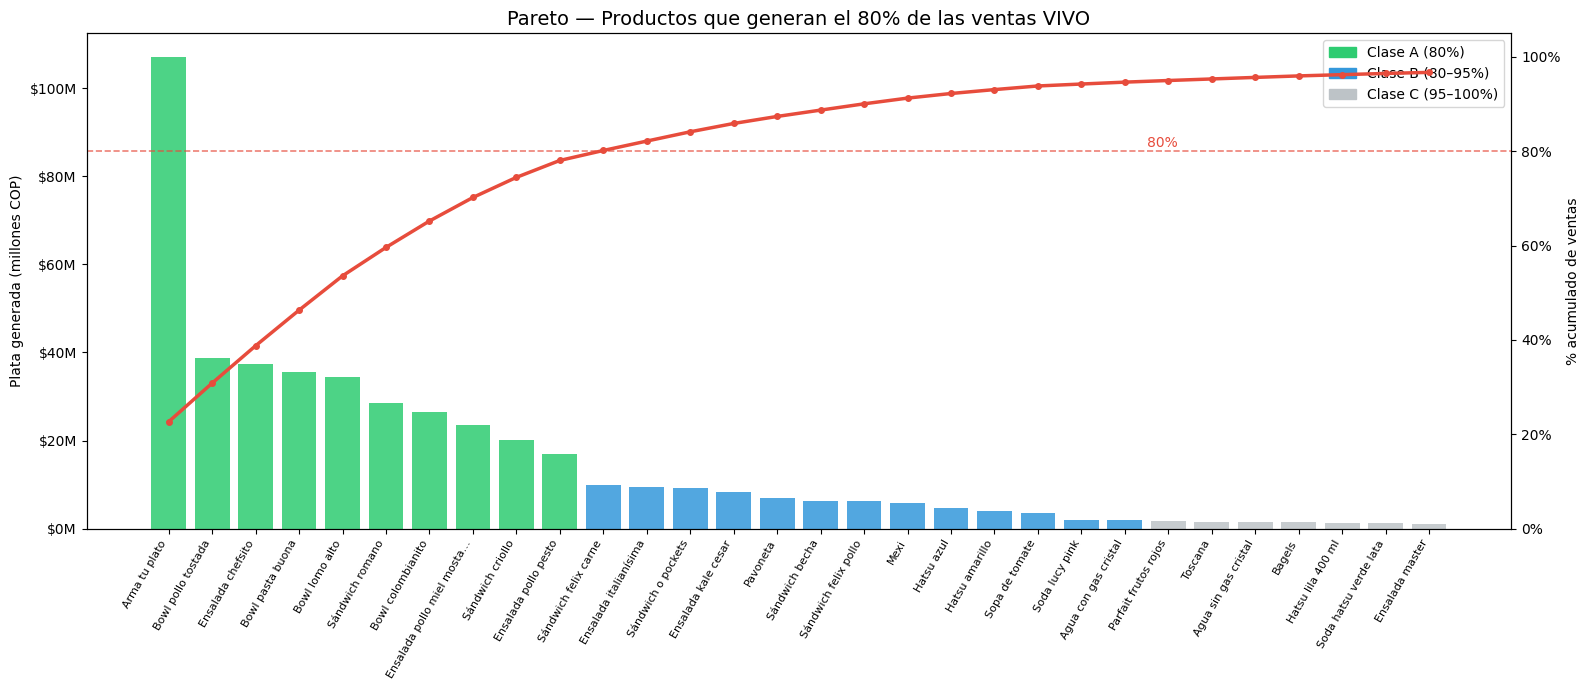


Resumen ABC:
Clase_ABC
C    44
B    13
A    10
Name: count, dtype: int64

Productos Clase A: 10
Plata generada Clase A: $368,812,551


In [26]:
# ── PASO 1: ordenar PRIMERO ───────────────────────────────────────
info_productos=info_productos[info_productos["Categoria_Matriz"]=="ESTRELLA (Alto Vol / Alto $)"]
info_productos = info_productos.sort_values('Plata generada', ascending=False).reset_index(drop=True)



# ── PASO 2: calcular pct DESPUÉS de ordenar ───────────────────────

total = info_productos['Plata generada'].sum()

info_productos['pct']      = info_productos['Plata generada'] / total

info_productos['pct_acum'] = info_productos['pct'].cumsum()



# ── PASO 3: clasificar ABC ────────────────────────────────────────

condiciones = [

    info_productos['pct_acum'] <= 0.80,

    info_productos['pct_acum'] <= 0.95,

]

info_productos['Clase_ABC'] = np.select(condiciones, ['A', 'B'], default='C')



# ── PASO 4: graficar ──────────────────────────────────────────────

n_mostrar = min(30, len(info_productos))

df_plot   = info_productos.head(n_mostrar)



colores = df_plot['Clase_ABC'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})



fig, ax1 = plt.subplots(figsize=(16, 7))



# Barras — plata generada

ax1.bar(range(n_mostrar), df_plot['Plata generada'] / 1_000_000, color=colores, alpha=0.85)

ax1.set_ylabel('Plata generada (millones COP)')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))



# Línea acumulada (eje derecho)

ax2 = ax1.twinx()

ax2.plot(range(n_mostrar), df_plot['pct_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)

ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)

ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de ventas')

ax2.set_ylim(0, 105)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))



# Etiquetas eje X

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]

ax1.set_xticks(range(n_mostrar))

ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)



# Leyenda

leyenda = [

    Patch(color='#2ecc71', label='Clase A (80%)'),

    Patch(color='#3498db', label='Clase B (80–95%)'),

    Patch(color='#bdc3c7', label='Clase C (95–100%)'),

]

ax1.legend(handles=leyenda, loc='upper right')



plt.title('Pareto — Productos que generan el 80% de las ventas VIVO', fontsize=14)

plt.tight_layout()

plt.show()



print(f"\nResumen ABC:")

print(info_productos['Clase_ABC'].value_counts())

print(f"\nProductos Clase A: {(info_productos['Clase_ABC'] == 'A').sum()}")

print(f"Plata generada Clase A: ${info_productos[info_productos['Clase_ABC']=='A']['Plata generada'].sum():,.0f}")


### Mostar datos detallados de cada producto CLASE A en plata generada

In [27]:
# 1. Extraer los productos que quedaron clasificados como 'A'
productos_clase_a = info_productos[info_productos['Clase_ABC'] == 'A'].copy()

# 2. Imprimir el encabezado con el conteo
print(f" ENFOQUE ESTRATÉGICO: PRODUCTOS CLASE A ({len(productos_clase_a)} ítems)")
print("Estos productos generan el 80% de tus ingresos estrella.")
print("=" * 95)

# 3. Mostrar la tabla formateada
# Seleccionamos las columnas que dan contexto: Nombre, Plata y el acumulado
columnas_finales = ['Nombre', 'Plata generada', 'pct', 'pct_acum']

print(productos_clase_a[columnas_finales].to_string(
    index=False,
    formatters={
        'Plata generada': lambda x: f"${x:,.0f}",
        'pct': lambda x: f"{x*100:.1f}%",
        'pct_acum': lambda x: f"{x*100:.1f}%"
    }
))

print("=" * 95)
print(f" TOTAL VENTA CLASE A: ${productos_clase_a['Plata generada'].sum():,.0f}")


 ENFOQUE ESTRATÉGICO: PRODUCTOS CLASE A (10 ítems)
Estos productos generan el 80% de tus ingresos estrella.
                     Nombre Plata generada   pct pct_acum
              Arma tu plato   $107,097,501 22.7%    22.7%
         Bowl pollo tostada    $38,669,700  8.2%    30.8%
          Ensalada chefsito    $37,435,500  7.9%    38.8%
           Bowl pasta buona    $35,651,850  7.5%    46.3%
             Bowl lomo alto    $34,361,900  7.3%    53.6%
            Sándwich romano    $28,473,750  6.0%    59.6%
          Bowl colombianito    $26,451,300  5.6%    65.2%
Ensalada pollo miel mostaza    $23,568,450  5.0%    70.2%
           Sándwich criollo    $20,143,600  4.3%    74.5%
       Ensalada pollo pesto    $16,959,000  3.6%    78.1%
 TOTAL VENTA CLASE A: $368,812,551


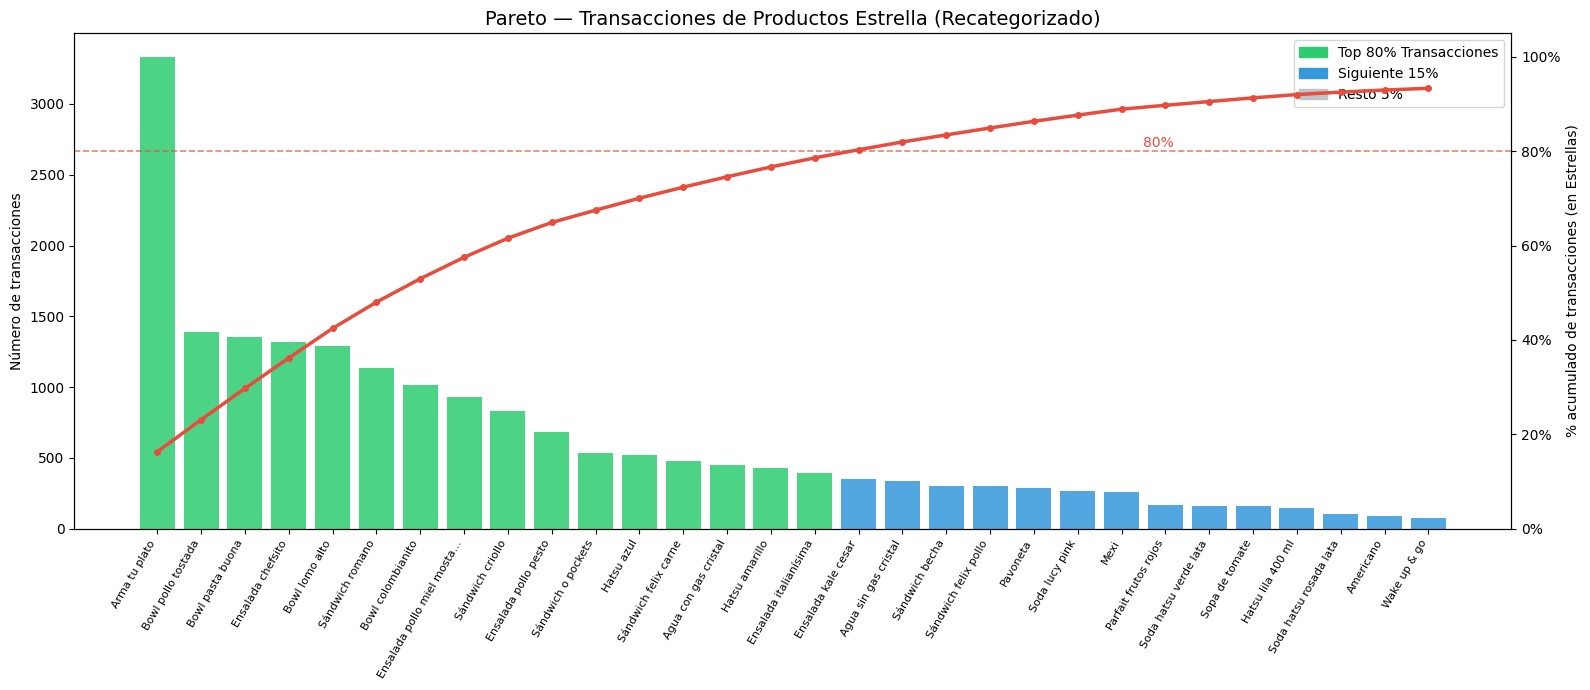

In [28]:
# 1. Filtrar solo los productos Estrella
df_estrella = info_productos[info_productos["Categoria_Matriz"] == "ESTRELLA (Alto Vol / Alto $)"].copy()

# 2. Ordenar por transacciones de mayor a menor
df_estrella = df_estrella.sort_values('transacciones', ascending=False).reset_index(drop=True)

# 3. Recalcular porcentajes sobre este nuevo total
total_trans_estrella = df_estrella['transacciones'].sum()
df_estrella['pct_trans']      = df_estrella['transacciones'] / total_trans_estrella
df_estrella['pct_trans_acum'] = df_estrella['pct_trans'].cumsum()

# 4. RECATEGORIZAR ABC (Solo para este grupo)
# Esto hará que los más vendidos de este grupo salgan en verde (A)
condiciones_estrella = [
    df_estrella['pct_trans_acum'] <= 0.80,
    df_estrella['pct_trans_acum'] <= 0.95,
]
df_estrella['Clase_ABC_Estrella'] = np.select(condiciones_estrella, ['A', 'B'], default='C')

# 5. Configurar visualización
n_mostrar = min(30, len(df_estrella))
df_plot = df_estrella.head(n_mostrar).copy()
colores = df_plot['Clase_ABC_Estrella'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})

# ── GRAFICAR ──────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 7))
ax1.bar(range(n_mostrar), df_plot['transacciones'], color=colores, alpha=0.85)
ax1.set_ylabel('Número de transacciones')

ax2 = ax1.twinx()
ax2.plot(range(n_mostrar), df_plot['pct_trans_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de transacciones (en Estrellas)')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]
ax1.set_xticks(range(n_mostrar))
ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)

leyenda = [
    Patch(color='#2ecc71', label='Top 80% Transacciones'), 
    Patch(color='#3498db', label='Siguiente 15%'), 
    Patch(color='#bdc3c7', label='Resto 5%')
]
ax1.legend(handles=leyenda, loc='upper right')

plt.title('Pareto — Transacciones de Productos Estrella (Recategorizado)', fontsize=14)
plt.tight_layout()
plt.show()


In [29]:
# 1. Filtrar los productos que son Clase A en transacciones dentro de Estrellas
productos_a_trans = df_estrella[df_estrella['Clase_ABC_Estrella'] == 'A'].copy()

print(f" REPORTE: TOP TRANSACCIONES (CLASE A - ESTRELLAS)")
print(f"Estos {len(productos_a_trans)} productos mueven el 80% del volumen de tus platos estrella.")
print("=" * 95)

# 2. Seleccionar columnas relevantes para este análisis de volumen
columnas_volumen = ['Nombre', 'transacciones', 'pct_trans', 'pct_trans_acum']

# 3. Imprimir con formato limpio
print(productos_a_trans[columnas_volumen].to_string(
    index=False,
    formatters={
        'transacciones': lambda x: f"{x:,.0f}",
        'pct_trans': lambda x: f"{x*100:.1f}%",
        'pct_trans_acum': lambda x: f"{x*100:.1f}%"
    }
))

print("=" * 95)
print(f" TOTAL TRANSACCIONES CLASE A: {productos_a_trans['transacciones'].sum():,.0f}")


 REPORTE: TOP TRANSACCIONES (CLASE A - ESTRELLAS)
Estos 16 productos mueven el 80% del volumen de tus platos estrella.
                     Nombre transacciones pct_trans pct_trans_acum
              Arma tu plato         3,332     16.3%          16.3%
         Bowl pollo tostada         1,387      6.8%          23.1%
           Bowl pasta buona         1,357      6.6%          29.7%
          Ensalada chefsito         1,315      6.4%          36.2%
             Bowl lomo alto         1,287      6.3%          42.5%
            Sándwich romano         1,136      5.6%          48.0%
          Bowl colombianito         1,015      5.0%          53.0%
Ensalada pollo miel mostaza           928      4.5%          57.5%
           Sándwich criollo           828      4.1%          61.6%
       Ensalada pollo pesto           681      3.3%          64.9%
         Sándwich o pockets           532      2.6%          67.5%
                 Hatsu azul           520      2.5%          70.1%
       Sán

## 2.3 Análisis ABC — Pareto por transacciones (productos Estrella)

Segundo Pareto, ahora ordenando por **número de transacciones** (frecuencia de compra). Esto complementa el análisis de ingresos: un producto puede generar menos plata pero ser comprado con mucha más frecuencia, lo que lo hace igual de crítico para la operación.


In [30]:
# 1. Extraer nombres de los Clase A de Ventas y de Transacciones (del segmento Estrella)
set_plata = set(info_productos[info_productos['Clase_ABC'] == 'A']['Nombre'])
set_trans = set(df_estrella[df_estrella['Clase_ABC_Estrella'] == 'A']['Nombre'])

# 2. Encontrar los que están en AMBOS (Intersección)
productos_criticos = list(set_plata.intersection(set_trans))

# 3. Crear el DataFrame final de productos críticos
df_criticos = info_productos[info_productos['Nombre'].isin(productos_criticos)].copy()

print(f"Se identificaron {len(productos_criticos)} productos críticos.")


Se identificaron 10 productos críticos.


## 2.4 Productos críticos — Intersección Clase A (plata) ∩ Clase A (transacciones)

Se identifican los productos que son **Clase A en ambos criterios**: los que más ingresos generan Y los que más frecuentemente se venden. Estos son los **productos críticos** sobre los que se construirán los modelos de pronóstico.

La intersección garantiza que pronosticamos productos que son vitales tanto en volumen como en ingresos.


In [31]:
# 1. Filtramos el DataFrame original para obtener solo los datos de los productos críticos
df_criticos = info_productos[info_productos['Nombre'].isin(productos_criticos)]

# 2. Ordenamos para que los más importantes salgan primero en la lista
df_criticos = df_criticos.sort_values('Plata generada', ascending=False)

print(f"Hay {len(productos_criticos)} productos que son Clase A en ambos criterios:\n")

for index, row in df_criticos.iterrows():
    nombre = row['Nombre']
    trans = row['transacciones']
    ventas = row['Plata generada']
    
    # Imprimimos con formato de miles y moneda para que sea profesional
    print(f" - {nombre[:30]:<30} | Transacciones: {int(trans):>4} | Ventas: ${ventas:,.0f}")


Hay 10 productos que son Clase A en ambos criterios:

 - Arma tu plato                  | Transacciones: 3332 | Ventas: $107,097,501
 - Bowl pollo tostada             | Transacciones: 1387 | Ventas: $38,669,700
 - Ensalada chefsito              | Transacciones: 1315 | Ventas: $37,435,500
 - Bowl pasta buona               | Transacciones: 1357 | Ventas: $35,651,850
 - Bowl lomo alto                 | Transacciones: 1287 | Ventas: $34,361,900
 - Sándwich romano                | Transacciones: 1136 | Ventas: $28,473,750
 - Bowl colombianito              | Transacciones: 1015 | Ventas: $26,451,300
 - Ensalada pollo miel mostaza    | Transacciones:  928 | Ventas: $23,568,450
 - Sándwich criollo               | Transacciones:  828 | Ventas: $20,143,600
 - Ensalada pollo pesto           | Transacciones:  681 | Ventas: $16,959,000


# 3. Preparar datos para el pronóstico

Una vez identificados los **productos críticos** (Clase A en ventas y en transacciones dentro del segmento Estrella), se prepara la serie de tiempo que alimentará los modelos de pronóstico.

Los pasos son:
1. Filtrar `dataset_p` para quedarse solo con los productos críticos → `ventas_criticas`
2. Definir el **calendario académico** de la Universidad de los Andes (vacaciones, recesos, exámenes) para que Prophet lo use como regresor externo
3. Definir las funciones de preparación de serie semanal y entrenamiento de Prophet


In [32]:
# Filtrar solo las filas de los productos críticos identificados
ventas_criticas = dataset_p[dataset_p["Nombre"].isin(productos_criticos)].reset_index()

# Eliminar columna 'index' que queda del reset_index anterior
ventas_criticas.drop(columns=["index"], inplace=True)

ventas_criticas.head()


,Fecha,Nombre,Cantidad,Total
0,2024-08-05,Bowl colombianito,1.0,20700.0
1,2024-08-05,Bowl pollo tostada,1.0,20000.0
2,2024-08-05,Bowl colombianito,1.0,20000.0
3,2024-08-05,Bowl pollo tostada,1.0,20000.0
4,2024-08-05,Bowl colombianito,1.0,23000.0


### Calendario académico — DataFrame de vacaciones para Prophet

Prophet acepta un DataFrame `holidays` con columnas `holiday`, `ds`, `lower_window` y `upper_window` que le indica qué días tienen comportamiento atípico.

Se codifican los siguientes eventos para 2024, 2025 y 2026:
| Tipo | Efecto esperado en ventas |
|---|---|
| `vacaciones_verano` / `vacaciones_invierno` | **↓ fuerte**: campus casi vacío |
| `semana_receso_verano` / `semana_receso_invierno` | **↓ moderado**: muchos estudiantes viajan |
| `semana_santa` | **↓ moderado**: festivos nacionales |
| `examenes_finales` | **↓ leve**: estudiantes comen menos fuera |


In [33]:
vacaciones = pd.concat([

    # ════════════════════════════════════════════════════════════════
    # 2024
    # ════════════════════════════════════════════════════════════════

    # Semana Santa 2024 (fecha estándar colombiana)
    pd.DataFrame({
        'holiday': 'semana_santa',
        'ds': pd.date_range('2024-03-24', '2024-03-30', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana de receso 2024-I
    pd.DataFrame({
        'holiday': 'semana_receso_verano',
        'ds': pd.date_range('2024-03-18', '2024-03-23', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2024-I
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2024-05-27', '2024-06-01', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones verano 2024: fin exámenes 2024-I → inicio 2024-II
    # Jun 02 → Ago 04 (Ago 05 es el primer día de clases)
    pd.DataFrame({
        'holiday': 'vacaciones_verano',
        'ds': pd.date_range('2024-06-02', '2024-08-04', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana de receso 2024-II
    pd.DataFrame({
        'holiday': 'semana_receso_invierno',
        'ds': pd.date_range('2024-09-30', '2024-10-05', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2024-II
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2024-12-02', '2024-12-07', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones invierno 2024→2025: fin exámenes 2024-II → inicio 2025-I
    # Dic 08 → Ene 20 (Ene 21 es el primer día de clases 2025-I)
    pd.DataFrame({
        'holiday': 'vacaciones_invierno',
        'ds': pd.date_range('2024-12-08', '2025-01-20', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # ════════════════════════════════════════════════════════════════
    # 2025
    # ════════════════════════════════════════════════════════════════

    # Semana de receso 2025-I
    pd.DataFrame({
        'holiday': 'semana_receso_verano',
        'ds': pd.date_range('2025-03-17', '2025-03-22', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana Santa 2025
    pd.DataFrame({
        'holiday': 'semana_santa',
        'ds': pd.date_range('2025-04-13', '2025-04-19', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2025-I
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2025-05-26', '2025-05-31', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones verano 2025: fin exámenes 2025-I → inicio 2025-II
    # Jun 01 → Ago 03 (Ago 04 es el primer día de clases 2025-II)
    pd.DataFrame({
        'holiday': 'vacaciones_verano',
        'ds': pd.date_range('2025-06-01', '2025-08-03', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana de receso 2025-II
    pd.DataFrame({
        'holiday': 'semana_receso_invierno',
        'ds': pd.date_range('2025-09-29', '2025-10-04', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2025-II
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2025-12-01', '2025-12-06', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones invierno 2025→2026: fin exámenes 2025-II → inicio 2026-I
    # Dic 07 → Ene 19 (Ene 20 es el primer día de clases 2026-I)
    pd.DataFrame({
        'holiday': 'vacaciones_invierno',
        'ds': pd.date_range('2025-12-07', '2026-01-19', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # ════════════════════════════════════════════════════════════════
    # 2026
    # ════════════════════════════════════════════════════════════════

    # Semana de receso 2026-I
    pd.DataFrame({
        'holiday': 'semana_receso_verano',
        'ds': pd.date_range('2026-03-16', '2026-03-21', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana Santa 2026
    pd.DataFrame({
        'holiday': 'semana_santa',
        'ds': pd.date_range('2026-03-29', '2026-04-04', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2026-I
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2026-05-25', '2026-05-30', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones verano 2026: fin exámenes 2026-I → inicio 2026-II
    # May 31 → Ago 02 (Ago 03 es el primer día de clases 2026-II)
    pd.DataFrame({
        'holiday': 'vacaciones_verano',
        'ds': pd.date_range('2026-05-31', '2026-08-02', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Semana de receso 2026-II
    pd.DataFrame({
        'holiday': 'semana_receso_invierno',
        'ds': pd.date_range('2026-09-28', '2026-10-03', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Exámenes finales 2026-II
    pd.DataFrame({
        'holiday': 'examenes_finales',
        'ds': pd.date_range('2026-11-30', '2026-12-05', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    # Vacaciones invierno 2026→2027: fin exámenes 2026-II → inicio 2027-I
    # Dic 06 → Ene 18 (siguiendo el patrón ~6 semanas)
    pd.DataFrame({
        'holiday': 'vacaciones_invierno',
        'ds': pd.date_range('2026-12-06', '2027-01-18', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),

    pd.DataFrame({
    'holiday': 'induccion_pregrado',
    'ds': pd.to_datetime(['2024-01-17', '2024-01-18', '2024-01-19',  # 2024-I 
                          '2024-07-31', '2024-08-01', '2024-08-02',  # 2024-II 
                          '2025-01-15', '2025-01-16', '2025-01-17',  # 2025-I  ~estimado
                          '2025-07-30', '2025-07-31', '2025-08-01',  # 2025-II ~estimado
                          '2026-01-13', '2026-01-14', '2026-01-15',  # 2026-I  
                          '2026-07-28', '2026-07-29', '2026-07-30']),# 2026-II ~estimado
    'lower_window': 0, 'upper_window': 0
}),

]).reset_index(drop=True)

# Verificación
print(vacaciones.groupby('holiday')['ds'].agg(['min', 'max', 'count']))


                              min        max  count
holiday                                            
examenes_finales       2024-05-27 2026-12-05     36
induccion_pregrado     2024-01-17 2026-07-30     18
semana_receso_invierno 2024-09-30 2026-10-03     18
semana_receso_verano   2024-03-18 2026-03-21     18
semana_santa           2024-03-24 2026-04-04     21
vacaciones_invierno    2024-12-08 2027-01-18    132
vacaciones_verano      2024-06-02 2026-08-02    192


### Funciones auxiliares: preparar serie y entrenar Prophet

Se definen dos funciones reutilizables:

**`preparar_serie_semanal(df, nombre_producto)`**
- Filtra las ventas del producto dado
- Agrupa por semana (lunes como inicio de semana)
- Rellena semanas sin ventas con `0` para tener una serie continua
- Retorna un DataFrame con columnas `ds` (fecha) e `y` (unidades vendidas)

**`entrenar_prophet(serie)`**
- Crea un modelo Prophet con estacionalidad anual + multiplicativa
- Incluye el calendario académico y los festivos colombianos (`add_country_holidays`)
- Genera predicciones para 30 semanas hacia adelante
- Recorta predicciones negativas a 0 (ventas no pueden ser negativas)


In [34]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import warnings
warnings.filterwarnings('ignore')

def preparar_serie_semanal(df, nombre_producto):
    df = df.copy()
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    
    # 1. Crear el "Calendario Maestro" de la tienda (Lunes a Lunes)
    f_min, f_max = df['Fecha'].min(), df['Fecha'].max()
    lunes_inicio = f_min - pd.Timedelta(days=f_min.weekday())
    lunes_fin    = f_max - pd.Timedelta(days=f_max.weekday())
    rango_maestro = pd.date_range(lunes_inicio, lunes_fin, freq='W-MON')

    # 2. Agrupar TODO el dataframe por lunes primero
    # Esto asegura que todas las fechas válidas del restaurante existan
    df['ds'] = df['Fecha'].dt.floor('D') - df['Fecha'].dt.weekday.map(lambda x: pd.Timedelta(days=x))
    
    # 3. Filtrar el producto DESPUÉS de haber normalizado las fechas
    df_prod = df[df['Nombre'] == nombre_producto]
    
    # 4. Agrupar ventas del producto por esos lunes
    serie_producto = df_prod.groupby('ds')['Cantidad'].sum().reset_index()
    
    # 5. Cruzar con el rango maestro (Aquí es donde evitamos los ceros falsos)
    # Usamos un merge 'right' para que mande el calendario de lunes
    serie_final = pd.merge(
        serie_producto, 
        pd.DataFrame({'ds': rango_maestro}), 
        on='ds', 
        how='right'
    ).fillna(0) # Solo será 0 si de verdad ese producto no se vendió esa semana
    
    serie_final = serie_final.rename(columns={'Cantidad': 'y'}).sort_values('ds')
    
    return serie_final[['ds', 'y']]

def entrenar_prophet(serie):
    modelo = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        holidays=vacaciones,
        changepoint_prior_scale=0.5,
        holidays_prior_scale=20.0
    )
    
    modelo.add_seasonality(
        name='semestral',
        period=24,
        fourier_order=5
    )
    
    modelo.add_country_holidays(country_name='CO')
    modelo.fit(serie)
    
    futuro = modelo.make_future_dataframe(periods=16, freq='W-MON')
    forecast = modelo.predict(futuro)
    
    forecast['yhat']       = np.ceil(forecast['yhat'].clip(lower=0)).astype(int)
    forecast['yhat_lower'] = np.ceil(forecast['yhat_lower'].clip(lower=0)).astype(int)
    forecast['yhat_upper'] = np.ceil(forecast['yhat_upper'].clip(lower=0)).astype(int)
    
    return modelo, forecast


## 4. Prototipo del modelo — "Arma tu plato"

Se usa el producto **"Arma tu plato"** (Grande + Mediano combinados) como caso de prueba para desarrollar y validar el pipeline completo antes de aplicarlo a todos los productos críticos.

> **Nota histórica:** Entre octubre y diciembre 2024 el local estuvo cerrado por remodelación. Ese período se excluye de la serie antes de entrenar.

In [35]:
serie_completa = preparar_serie_semanal(ventas_criticas, 'Arma tu plato')
print(f"Semanas totales: {len(serie_completa)}")
print(f"Semanas con ventas: {(serie_completa['y'] > 0).sum()}")
# Ordenar por la columna de fecha (ds) de forma descendente y mostrar 10
serie_completa.sort_values('ds', ascending=False).head(10)


Semanas totales: 86
Semanas con ventas: 63


,ds,y
85,2026-03-23,86.0
84,2026-03-16,5.0
83,2026-03-09,118.0
82,2026-03-02,62.0
81,2026-02-23,112.0
80,2026-02-16,114.0
79,2026-02-09,146.0
78,2026-02-02,117.0
77,2026-01-26,170.0
76,2026-01-19,134.0


### Visualizar serie con calendario académico

Se grafican las ventas semanales sombreando los períodos del calendario Uniandes (recesos, vacaciones, exámenes) para entender visualmente qué eventos afectan la demanda.

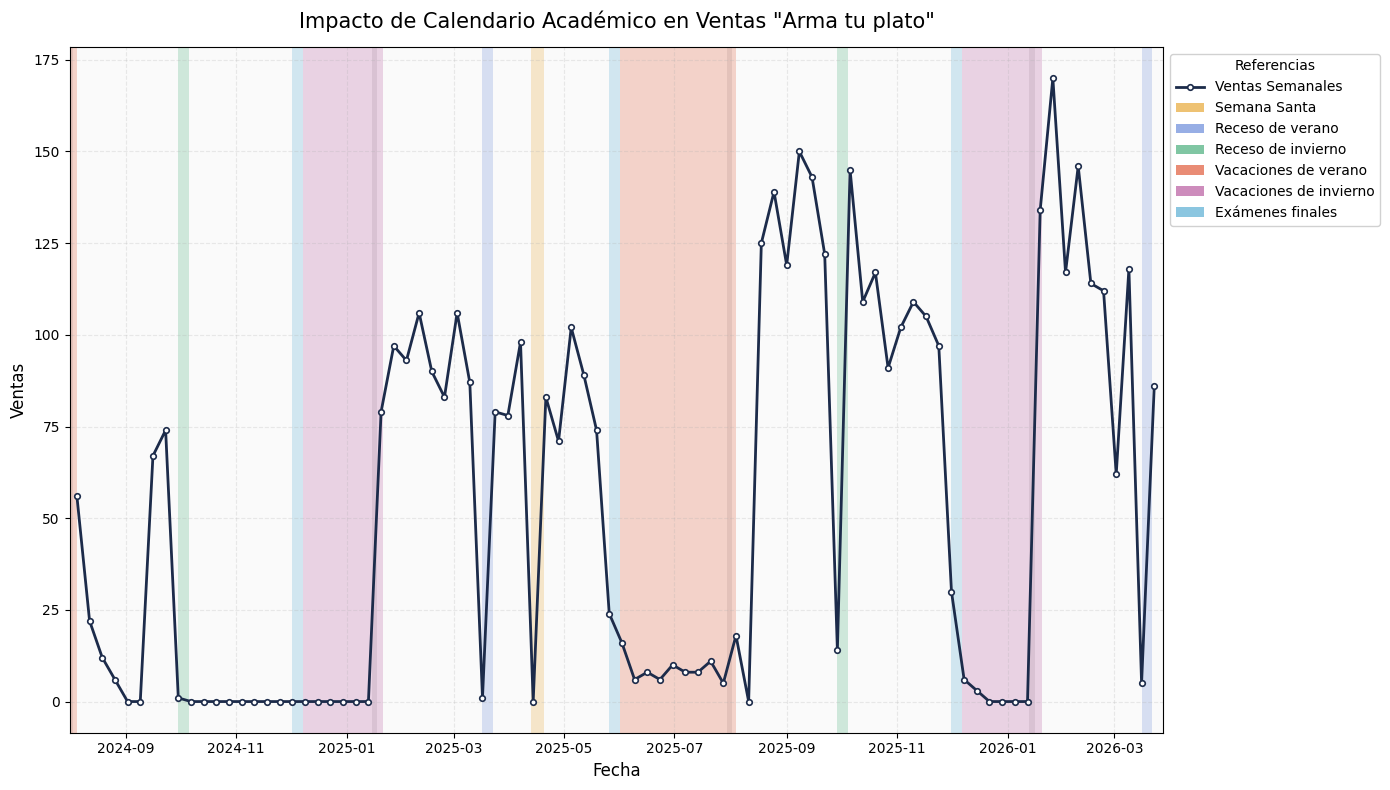

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Paleta más diferenciada por tipo ──────────────────────────────
HOLIDAY_COLORS = {
    'semana_santa':           '#E8A838',
    'semana_receso_verano':   '#6B8CDA',
    'semana_receso_invierno': '#4BAF7D',
    'vacaciones_verano':      '#E05C3A',
    'vacaciones_invierno':    '#B85BA0',
    'examenes_finales':       '#5AAED4',
}

HOLIDAY_LABELS = {
    'semana_santa':           'Semana Santa',
    'semana_receso_verano':   'Receso de verano',
    'semana_receso_invierno': 'Receso de invierno',
    'vacaciones_verano':      'Vacaciones de verano',
    'vacaciones_invierno':    'Vacaciones de invierno',
    'examenes_finales':       'Exámenes finales',
}

# ── Gráfico ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

# 1. Serie de tiempo con marker en cada punto semanal
ax.plot(
    serie_completa['ds'], serie_completa['y'],
    color='#1C2B4A',
    linewidth=2,
    marker='o',          # círculo en cada semana
    markersize=4,
    markerfacecolor='white',
    markeredgecolor='#1C2B4A',
    markeredgewidth=1.2,
    zorder=4
)

# 2. Sombrear periodos
for holiday, grupo in vacaciones.groupby('holiday'):
    color = HOLIDAY_COLORS.get(holiday, '#AAAAAA')

    fechas = grupo['ds'].sort_values()
    inicio = None
    fin_anterior = None

    for fecha in fechas:
        if inicio is None:
            inicio = fecha
            fin_anterior = fecha
        elif (fecha - fin_anterior).days <= 1:
            fin_anterior = fecha
        else:
            ax.axvspan(inicio, fin_anterior + pd.Timedelta(days=1),
                       color=color, alpha=0.25, linewidth=0, zorder=1)
            inicio = fecha
            fin_anterior = fecha

    if inicio is not None:
        ax.axvspan(inicio, fin_anterior + pd.Timedelta(days=1),
                   color=color, alpha=0.25, linewidth=0, zorder=1)

# 3. Leyenda
serie_handle = plt.Line2D(
    [0], [0],
    color='#1C2B4A', linewidth=2,
    marker='o', markersize=4,
    markerfacecolor='white', markeredgecolor='#1C2B4A', markeredgewidth=1.2,
    label='Ventas Semanales'
)

holiday_handles = [
    mpatches.Patch(
        facecolor=HOLIDAY_COLORS[h],
        alpha=0.7,
        label=HOLIDAY_LABELS[h]
    )
    for h in HOLIDAY_COLORS
    if h in vacaciones['holiday'].values
]

ax.legend(
    handles=[serie_handle] + holiday_handles,
    loc='upper left',
    bbox_to_anchor=(1, 1),
    framealpha=0.9,
    edgecolor='#CCCCCC',
    title='Referencias',
    title_fontsize=10
)

# 4. Personalización
ax.set_title(
    'Impacto de Calendario Académico en Ventas "Arma tu plato"',
    fontsize=15, pad=14
)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Ventas', fontsize=12)
ax.grid(True, alpha=0.25, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
ax.set_xlim(pd.Timestamp('2024-08-01'), pd.Timestamp('2026-03-28'))
plt.show()


### Manejar el período de cierre (oct–dic 2024)

El local estuvo **cerrado por remodelación** entre octubre y diciembre de 2024. Ese período genera ceros atípicos que confunden al modelo haciéndolo pensar que en Q4 siempre hay cero ventas.

**Solución:** 
1. Eliminar esas semanas de la serie de entrenamiento para no distorsionar la tendencia
2. Marcar esas semanas como holidays para marcar las ventas de esas semanas como atipicas

In [37]:
# Eliminar las semanas de oct-dic 2024 (período de cierre por remodelación)
# Estas semanas tienen y=0 que no representan demanda real, sino ausencia de operación
serie_completa = serie_completa[
    ~((serie_completa['ds'].dt.year == 2024) &
      (serie_completa['ds'].dt.month.isin([10, 11, 12])))
].reset_index(drop=True)

print(f"Semanas totales : {len(serie_completa)}")
print(f"Desde           : {serie_completa['ds'].min().date()}")
print(f"Hasta           : {serie_completa['ds'].max().date()}")
print(f"\nPrimeras semanas:")
print(serie_completa.head(10).to_string())


Semanas totales : 73
Desde           : 2024-08-05
Hasta           : 2026-03-23

Primeras semanas:
          ds     y
0 2024-08-05  56.0
1 2024-08-12  22.0
2 2024-08-19  12.0
3 2024-08-26   6.0
4 2024-09-02   0.0
5 2024-09-09   0.0
6 2024-09-16  67.0
7 2024-09-23  74.0
8 2024-09-30   1.0
9 2025-01-06   0.0


In [38]:
cierre_oct_dic_2024 = pd.DataFrame({
    'holiday': 'cierre_oct_dic_2024',
    'ds': pd.date_range('2024-10-01', '2024-12-31', freq='D'),
    'lower_window': 0,
    'upper_window': 0
})

vacaciones = pd.concat([vacaciones, cierre_oct_dic_2024]).reset_index(drop=True)

# Verificar
print(vacaciones[vacaciones['holiday'] == 'cierre_oct_dic_2024'][['ds']].agg(['min', 'max']))
print(f"Días agregados: {(vacaciones['holiday'] == 'cierre_oct_dic_2024').sum()}")


            ds
min 2024-10-01
max 2024-12-31
Días agregados: 92


### Entrenar Prophet sin el período de cierre + visualización del pronóstico

Se entrena un modelo limpio con la serie sin oct–dic 2024 y se genera el pronóstico para 26 semanas (~6 meses). El gráfico muestra:
- **Línea azul punteada**: ajuste del modelo en el histórico
- **Línea naranja**: pronóstico futuro
- **Puntos negros**: ventas reales
- **Banda naranja**: intervalo de confianza del pronóstico


In [39]:
modelo, forecast = entrenar_prophet(serie_completa)


17:17:39 - cmdstanpy - INFO - Chain [1] start processing
17:17:41 - cmdstanpy - INFO - Chain [1] done processing


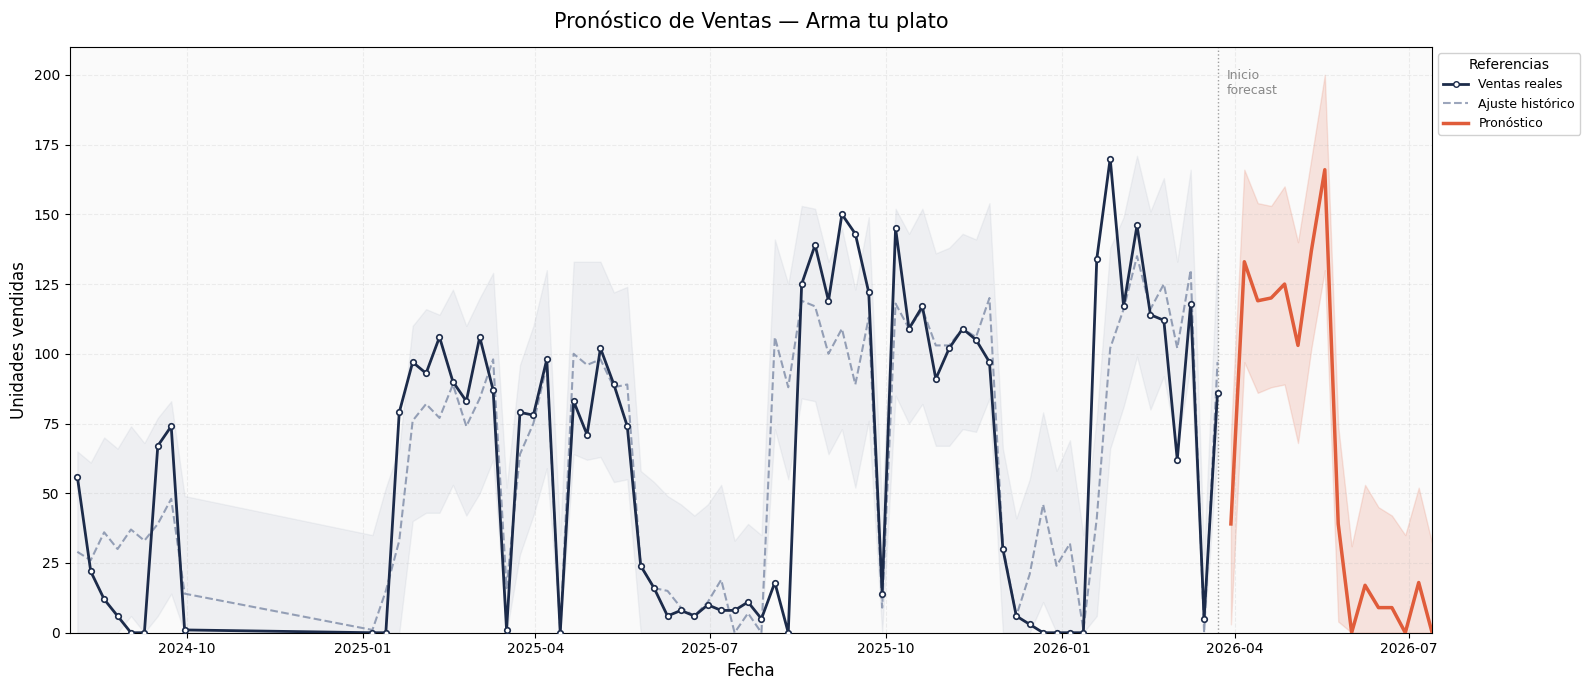

In [40]:
# Clampear yhat y bandas a 0 (ventas no pueden ser negativas)
forecast['yhat']       = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

fig, ax = plt.subplots(figsize=(16, 7))

ultimo_dato = serie_completa['ds'].max()
hist = forecast[forecast['ds'] <= ultimo_dato]
fut  = forecast[forecast['ds'] >  ultimo_dato]

# Banda de incertidumbre — más sutil en histórico
ax.fill_between(hist['ds'], hist['yhat_lower'], hist['yhat_upper'],
                color='#3A4F7A', alpha=0.06, zorder=1)
ax.fill_between(fut['ds'], fut['yhat_lower'], fut['yhat_upper'],
                color='#E05C3A', alpha=0.15, zorder=1)

# Líneas de predicción
ax.plot(hist['ds'], hist['yhat'],
        color='#3A4F7A', linewidth=1.5, linestyle='--',
        alpha=0.5, zorder=2, label='Ajuste histórico')
ax.plot(fut['ds'], fut['yhat'],
        color='#E05C3A', linewidth=2.5,
        zorder=3, label='Pronóstico')

# Datos reales
ax.plot(serie_completa['ds'], serie_completa['y'],
        color='#1C2B4A', linewidth=2,
        marker='o', markersize=4,
        markerfacecolor='white', markeredgecolor='#1C2B4A',
        markeredgewidth=1.2, zorder=4, label='Ventas reales')

# Línea vertical de corte
ax.axvline(ultimo_dato, color='#888888', linewidth=1,
           linestyle=':', alpha=0.8)
ax.text(ultimo_dato + pd.Timedelta(days=5),
        ax.get_ylim()[1] * 0.92,
        'Inicio\nforecast', fontsize=9, color='#888888')

# Forzar eje Y a no bajar de 0
ax.set_ylim(bottom=0)

# ── Leyenda ────────────────────────────────────────────────────────
serie_handles = [
    Line2D([0],[0], color='#1C2B4A', linewidth=2, marker='o',
           markersize=4, markerfacecolor='white',
           markeredgecolor='#1C2B4A', label='Ventas reales'),
    Line2D([0],[0], color='#3A4F7A', linewidth=1.5,
           linestyle='--', alpha=0.5, label='Ajuste histórico'),
    Line2D([0],[0], color='#E05C3A', linewidth=2.5, label='Pronóstico'),
]

ax.legend(
    handles=serie_handles,
    loc='upper left', bbox_to_anchor=(1, 1),
    framealpha=0.9, edgecolor='#CCCCCC',
    title='Referencias', title_fontsize=10,
    fontsize=9
)

ax.set_title('Pronóstico de Ventas — Arma tu plato',
             fontsize=15, pad=14)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Unidades vendidas', fontsize=12)
ax.grid(True, alpha=0.2, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')
ax.set_xlim(pd.Timestamp('2024-08-01'), fut['ds'].max())

plt.tight_layout()
plt.show()


## 5. Serie combinada — "Arma tu plato" (Grande + Mediano) — "Arma tu plato"

En lugar de modelar cada tamaño de plato por separado (serie corta y ruidosa), se **combina la demanda** de Grande (21k) y Mediano (18k) en una sola serie. 

**Razón:** Los dos productos son sustitutos cercanos y comparten el mismo patrón de demanda. Combinarlos da una serie con más señal y menos ruido, lo que mejora significativamente la calidad del pronóstico.


In [41]:
# Aplicar la misma limpieza del período de cierre a la serie combinada
serie_combinada=serie_completa
serie_combinada = serie_combinada[
    ~((serie_combinada['ds'].dt.year == 2024) &
      (serie_combinada['ds'].dt.month.isin([10, 11, 12])))
].reset_index(drop=True)

print(f"Semanas totales : {len(serie_combinada)}")
print(f"Desde           : {serie_combinada['ds'].min().date()}")
print(f"Hasta           : {serie_combinada['ds'].max().date()}")
print(f"Semanas en cero : {(serie_combinada['y'] == 0).sum()}")

# ── Entrenar modelo Prophet sobre la serie combinada ──────────────
modelo_combinado = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,    # granularidad semanal ya está en la serie
    daily_seasonality=False,
    holidays=vacaciones          # calendario académico Uniandes
)

modelo_combinado.fit(serie_combinada)

# ── Generar pronóstico para 26 semanas (~6 meses) ─────────────────
future = modelo_combinado.make_future_dataframe(periods=26, freq='W')
forecast_combinado = modelo_combinado.predict(future)

# Clampear predicciones negativas a 0 (ventas no pueden ser negativas)
forecast_combinado['yhat']       = forecast_combinado['yhat'].clip(lower=0)
forecast_combinado['yhat_lower'] = forecast_combinado['yhat_lower'].clip(lower=0)
forecast_combinado['yhat_upper'] = forecast_combinado['yhat_upper'].clip(lower=0)

#Poner las predicciones en 0 cuando el restaurante esta cerrado(0 ventas de Arma tu plato en una semana)
# 1. Obtenemos los índices donde el valor real es 0
indices_cero = serie_combinada[serie_combinada["y"] == 0].index

# 2. Aplicamos el cambio en el forecast usando esos índices
# .loc buscará esas fechas exactas en forecast_combinado y pondrá el yhat en 0
forecast_combinado.loc[forecast_combinado.index.isin(indices_cero), "yhat"] = 0

print(forecast_combinado[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10).to_string())


Semanas totales : 73
Desde           : 2024-08-05
Hasta           : 2026-03-23
Semanas en cero : 10


17:17:42 - cmdstanpy - INFO - Chain [1] start processing
17:17:43 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper
89 2026-07-19   48.176368   16.296346   80.008341
90 2026-07-26   51.770418   21.631815   79.753318
91 2026-08-02   58.963640   27.446252   88.493144
92 2026-08-09   92.626192   63.002169  121.633771
93 2026-08-16  109.725387   78.722438  139.590053
94 2026-08-23  125.750300   94.519634  154.310825
95 2026-08-30  134.419932  105.207134  165.980628
96 2026-09-06  137.095341  106.111366  166.726981
97 2026-09-13  143.186677  112.800879  169.760116
98 2026-09-20  159.246863  130.455316  191.247842


## 6. Feature Engineering

Se definen todas las variables que alimentarán al XGBoost. Los features capturan:
- **Calendario académico Uniandes**: semana académica (1-17), parciales, vacaciones
- **Lags**: ventas de semanas anteriores (1, 2, 4 semanas)
- **Medias móviles**: promedios de 4 y 8 semanas
- **Codificación cíclica**: mes y semana del año como seno/coseno
- **Eventos especiales**: flags binarios de holidays, vuelta a clases, post-vacaciones

In [42]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import numpy as np

# ── Feature engineering ────────────────────────────────────────────
def crear_features(serie, vacaciones):
    df = serie.copy()
    
    # Features de calendario
    df['mes']           = df['ds'].dt.month
    df['semana_año']    = df['ds'].dt.isocalendar().week.astype(int)
    df['trimestre']     = df['ds'].dt.quarter
    df['semestre'] = np.where(df['trimestre'] <= 2, 1, 2)
    
    # Lags (ventas semanas anteriores)
    # Lag condicional: si la semana anterior fue vacación, usar media histórica
    df['lag_1'] = df['y'].shift(1)
    
    df['lag_2']  = df['y'].shift(2)   # 2 semanas atrás
    df['lag_4']  = df['y'].shift(4)   # 1 mes atrás
    df['lag_52'] = df['y'].shift(52)  # mismo periodo año anterior
    
    # Rolling means
    df['rolling_4']  = df['y'].shift(1).rolling(4).mean()   # promedio 1 mes
    df['rolling_8']  = df['y'].shift(1).rolling(8).mean()   # promedio 2 meses
    
    # Features de vacaciones (binarias)
    for holiday in vacaciones['holiday'].unique():
        fechas_holiday = vacaciones[vacaciones['holiday'] == holiday]['ds']
        # Marcar semanas que contienen días de ese holiday
        df[f'hol_{holiday}'] = df['ds'].apply(
            lambda x: 
            int(any(
                (fechas_holiday >= x) & 
                (fechas_holiday < x + pd.Timedelta(days=7))
            ))
        )
    
    # Semanas antes/después de vacaciones (efecto anticipación)
    df['semanas_antes_verano'] = df['ds'].apply(
        lambda x: max(0, 4 - (
            vacaciones[vacaciones['holiday'] == 'vacaciones_verano']['ds'].min() - x
        ).days // 7) if (
            vacaciones[vacaciones['holiday'] == 'vacaciones_verano']['ds'].min() - x
        ).days > 0 else 0
    )
    #semana academica
    
    mapa_vacas = vacaciones.set_index('ds')['holiday'].to_dict()

    
    hitos_inicio = [pd.Timestamp('2024-01-22'), pd.Timestamp('2024-08-05'),
                pd.Timestamp('2025-01-20'), pd.Timestamp('2025-08-04'),
                pd.Timestamp('2026-01-19'), pd.Timestamp('2026-08-03')] # 19 de enero es SEMANA 1
    
    df['semana_academica'] = df['ds'].apply(lambda x: 
    # PRIORIDAD 1: Si es un inicio oficial, ES SEMANA 1 (Sin importar nada más)
    1 if x in hitos_inicio else 
    
    # PRIORIDAD 2: Hitos que "detienen" o "cambian" la demanda
    17 if 'finales' in mapa_vacas.get(x, '') else 
    0  if any(h in mapa_vacas.get(x, '') for h in ['receso', 'santa', 'induccion']) else 
    
    # PRIORIDAD 3: Si no es inicio, pero sigue siendo periodo de vacaciones
    -1 if 'vacaciones' in mapa_vacas.get(x, '') else 
    
    # PRIORIDAD 4: Conteo dinámico de semanas de clase
    (lambda inicio: 
        len([l for l in pd.date_range(inicio, x, freq='W-MON') 
             if not any(h in mapa_vacas.get(l, '') for h in ['receso', 'santa', 'finales', 'induccion'])])
    )(max([i for i in hitos_inicio if i <= x], default=pd.Timestamp('1900-01-01')))
)
    
    # Definimos las semanas críticas según tu conocimiento de Uniandes
    semanas_parciales_1 = [7, 8]
    semanas_parciales_2 = [12, 13]

    # Creamos las columnas en el DataFrame de features
    df['inicio_parciales_1'] = (df['semana_academica'] == 7).astype(int)  # caída fuerte
    df['fin_parciales_1']    = (df['semana_academica'] == 8).astype(int)  # recuperación
# Reemplaza es_parciales_1 en FEATURES

    df['inicio_parciales_2'] = (df['semana_academica'] == 12).astype(int)  # caída fuerte
    df['fin_parciales_2']    = (df['semana_academica'] == 13).astype(int)

    df['pre_evento'] = (df['semana_academica'].shift(-1) == 0).astype(int)

    # 1. Creamos los del MES (periodo = 12)
    df['mes_sin'] = np.sin(2 * np.pi * df['ds'].dt.month / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df['ds'].dt.month / 12)

    # 2. Creamos los de la SEMANA DEL AÑO (periodo = 52)
    # Usamos isocalendar() para ser precisos con las semanas
    df['semana_sin'] = np.sin(2 * np.pi * df['ds'].dt.isocalendar().week / 52)
    df['semana_cos'] = np.cos(2 * np.pi * df['ds'].dt.isocalendar().week / 52)

    df['vuelta_a_clases'] = df['semana_academica'].isin([1, 2]).astype(int)
    df['post_vacaciones'] = (
    (df['semana_academica'] == 1) | 
    (df['semana_academica'].shift(1) == -1)  # -1 = semana de receso
).astype(int)
    df['lag_1_clean'] = df.apply(
    lambda row: df[df['semana_academica'] == row['semana_academica']]['y'].mean()if row['lag_1'] == 0 and row['semana_academica'] in [1, 2]
    else row['lag_1'], axis=1)
    df['lag_x_parciales'] = df['lag_1'] * df['inicio_parciales_1']


    
    return df

# ── Aplicar features ───────────────────────────────────────────────
df_features = crear_features(serie_combinada, vacaciones)

print("Features creadas:")
print(df_features.columns.tolist())
print(f"\nShape: {df_features.shape}")
print(df_features.tail(5).to_string())
df_features


Features creadas:
['ds', 'y', 'mes', 'semana_año', 'trimestre', 'semestre', 'lag_1', 'lag_2', 'lag_4', 'lag_52', 'rolling_4', 'rolling_8', 'hol_semana_santa', 'hol_semana_receso_verano', 'hol_examenes_finales', 'hol_vacaciones_verano', 'hol_semana_receso_invierno', 'hol_vacaciones_invierno', 'hol_induccion_pregrado', 'hol_cierre_oct_dic_2024', 'semanas_antes_verano', 'semana_academica', 'inicio_parciales_1', 'fin_parciales_1', 'inicio_parciales_2', 'fin_parciales_2', 'pre_evento', 'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos', 'vuelta_a_clases', 'post_vacaciones', 'lag_1_clean', 'lag_x_parciales']

Shape: (73, 35)
           ds      y  mes  semana_año  trimestre  semestre  lag_1  lag_2  lag_4  lag_52  rolling_4  rolling_8  hol_semana_santa  hol_semana_receso_verano  hol_examenes_finales  hol_vacaciones_verano  hol_semana_receso_invierno  hol_vacaciones_invierno  hol_induccion_pregrado  hol_cierre_oct_dic_2024  semanas_antes_verano  semana_academica  inicio_parciales_1  fin_parciales

,ds,y,mes,semana_año,trimestre,semestre,lag_1,lag_2,lag_4,lag_52,...,fin_parciales_2,pre_evento,mes_sin,mes_cos,semana_sin,semana_cos,vuelta_a_clases,post_vacaciones,lag_1_clean,lag_x_parciales
0,2024-08-05,56.0,8,32,3,2,NaN,NaN,NaN,NaN,...,0,0,-0.866025,-5.000000e-01,-0.663123,-0.748511,1,1,NaN,NaN
1,2024-08-12,22.0,8,33,3,2,56.0,NaN,NaN,NaN,...,0,0,-0.866025,-5.000000e-01,-0.748511,-0.663123,1,0,56.0,0.0
2,2024-08-19,12.0,8,34,3,2,22.0,56.0,NaN,NaN,...,0,0,-0.866025,-5.000000e-01,-0.822984,-0.568065,0,0,22.0,0.0
3,2024-08-26,6.0,8,35,3,2,12.0,22.0,NaN,NaN,...,0,0,-0.866025,-5.000000e-01,-0.885456,-0.464723,0,0,12.0,0.0
4,2024-09-02,0.0,9,36,3,2,6.0,12.0,56.0,NaN,...,0,0,-1.000000,-1.836970e-16,-0.935016,-0.354605,0,0,6.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,2026-02-23,112.0,2,9,1,1,114.0,146.0,170.0,83.0,...,0,0,0.866025,5.000000e-01,0.885456,0.464723,0,0,114.0,0.0
69,2026-03-02,62.0,3,10,1,1,112.0,114.0,117.0,106.0,...,0,0,1.000000,6.123234e-17,0.935016,0.354605,0,0,112.0,112.0
70,2026-03-09,118.0,3,11,1,1,62.0,112.0,146.0,87.0,...,0,1,1.000000,6.123234e-17,0.970942,0.239316,0,0,62.0,0.0
71,2026-03-16,5.0,3,12,1,1,118.0,62.0,114.0,1.0,...,0,0,1.000000,6.123234e-17,0.992709,0.120537,0,0,118.0,0.0


## 7. Modelo Híbrido — Prophet + XGBoost

**Idea:** Prophet captura bien la tendencia y la estacionalidad (largo plazo), pero falla en patrones de corto plazo. XGBoost captura bien los patrones recientes (lags) pero no tiene estructura para el largo plazo.

**Estrategia híbrida:**
1. Prophet predice la serie → genera `yhat` (tendencia base)
2. XGBoost aprende los **residuos** de Prophet (lo que Prophet no capturó)
3. Predicción final = `yhat_prophet + yhat_residuo_xgb`

Esto combina lo mejor de ambos mundos: la estructura temporal de Prophet y la capacidad de corrección de XGBoost.


In [43]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

smape = lambda y, yhat: (2 * abs(y - yhat) / (abs(y) + abs(yhat) + 1e-8)).mean()

# ══════════════════════════════════════════════════════════════
# 1. RESIDUOS DE PROPHET
# ══════════════════════════════════════════════════════════════
forecast_hist = forecast_combinado[
    forecast_combinado['ds'].isin(serie_combinada['ds'])
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

for col in ['yhat', 'yhat_lower', 'yhat_upper']:
    forecast_hist[col] = forecast_hist[col].clip(0)

df_hibrido = serie_combinada.merge(forecast_hist, on='ds', how='left')
df_hibrido['residuo'] = df_hibrido['y'] - df_hibrido['yhat']

# ══════════════════════════════════════════════════════════════
# 2. FEATURES
# ══════════════════════════════════════════════════════════════
df_hibrido_feat = crear_features(df_hibrido[['ds', 'y']], vacaciones)
df_hibrido_feat = df_hibrido_feat.merge(
    df_hibrido[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'residuo']],
    on='ds', how='left'
)

FEATURES_HIBRIDO = [
    'yhat', 'yhat_lower', 'yhat_upper',
    'semana_academica',
    'pre_evento',
    'inicio_parciales_1', 'fin_parciales_1',
    'inicio_parciales_2', 'fin_parciales_2',
    'mes_sin', 'mes_cos',
    'semana_sin', 'semana_cos',
    'lag_1_clean', 'rolling_4', 'vuelta_a_clases', 'post_vacaciones'
]

# ══════════════════════════════════════════════════════════════
# 3. SPLIT: 65% train | 15% val | 20% test
# ══════════════════════════════════════════════════════════════
df_modelo_h = df_hibrido_feat.dropna(subset=FEATURES_HIBRIDO).copy()
n          = len(df_modelo_h)
corte_val  = int(0.65 * n)
corte_test = int(0.80 * n)

train_h = df_modelo_h.iloc[:corte_val]
val_h   = df_modelo_h.iloc[corte_val:corte_test]
test_h  = df_modelo_h.iloc[corte_test:]

print(f"Train : {len(train_h)} semanas → {train_h['ds'].min().date()} a {train_h['ds'].max().date()}")
print(f"Val   : {len(val_h)} semanas  → {val_h['ds'].min().date()} a {val_h['ds'].max().date()}")
print(f"Test  : {len(test_h)} semanas  → {test_h['ds'].min().date()} a {test_h['ds'].max().date()}")


Train : 44 semanas → 2024-09-02 a 2025-09-29
Val   : 11 semanas  → 2025-10-06 a 2025-12-15
Test  : 14 semanas  → 2025-12-22 a 2026-03-23


### Búsqueda de hiperparámetros con Optuna (walk-forward sobre val set)

Optuna con búsqueda bayesiana optimiza los hiperparámetros del XGBoost. Cada trial se evalúa con **walk-forward** sobre el val set: para cada semana, entrena con todo lo anterior y predice la siguiente. Esto respeta el orden temporal y evita data leakage.

In [44]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.25, log=True),
        max_depth        = trial.suggest_int('max_depth', 2, 7),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 15),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 2.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 5.0),
        random_state=42, n_jobs=-1
    )
    errores = []
    for i in range(corte_val, corte_test):
        train_wf         = df_modelo_h.iloc[:i]
        siguiente_semana = df_modelo_h.iloc[[i]]
        m = XGBRegressor(**params)
        m.fit(train_wf[FEATURES_HIBRIDO], train_wf['residuo'])
        pred = (siguiente_semana['yhat'].values + m.predict(siguiente_semana[FEATURES_HIBRIDO])).clip(0)
        errores.append(mean_absolute_error(siguiente_semana['y'].values, pred))
    return float(np.mean(errores))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)
best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1})
print(f"Mejores params: {best_params}")
print(f"MAE val walk-forward: {study.best_value:.1f}")


  0%|          | 0/50 [00:00<?, ?it/s]

Mejores params: {'n_estimators': 338, 'learning_rate': 0.24331398987013123, 'max_depth': 5, 'subsample': 0.8229082407706511, 'colsample_bytree': 0.5754594933803324, 'min_child_weight': 1, 'reg_alpha': 0.5091336176665602, 'reg_lambda': 1.9361794823383984, 'random_state': 42, 'n_jobs': -1}
MAE val walk-forward: 7.0


### Evaluación final en test set (walk-forward)

Con los hiperparámetros óptimos, se evalúa en el **test set** usando walk-forward: para cada semana de test, se re-entrena con todos los datos anteriores y se predice solo esa semana. Esta es la evaluación más realista porque simula el uso real del modelo.

In [45]:
errores_test      = []
reales_test       = []
predicciones_test = []

for i in range(corte_test, n):
    train_wf         = df_modelo_h.iloc[:i]
    siguiente_semana = df_modelo_h.iloc[[i]]

    model = XGBRegressor(**best_params)
    model.fit(train_wf[FEATURES_HIBRIDO], train_wf['residuo'])

    pred_residuo = model.predict(siguiente_semana[FEATURES_HIBRIDO])
    pred_final   = (siguiente_semana['yhat'].values + pred_residuo).clip(0)
    real         = siguiente_semana['y'].values

    errores_test.append(mean_absolute_error(real, pred_final))
    reales_test.append(real[0])
    predicciones_test.append(pred_final[0])

reales_test       = np.array(reales_test)
predicciones_test = np.array(predicciones_test)

# Forzar 0 cuando Prophet ya predice 0 (semanas de vacaciones)
predicciones_test = np.where(test_h['yhat'].values == 0, 0, predicciones_test)

mae_test   = mean_absolute_error(reales_test, predicciones_test)
smape_test = smape(reales_test, predicciones_test)
sesgo_test = (predicciones_test - reales_test).mean()

# Métricas solo en semanas activas (excluir vacaciones con y=0)
mask_activo  = reales_test > 0
smape_activo = smape(reales_test[mask_activo], predicciones_test[mask_activo])
mae_activo   = mean_absolute_error(reales_test[mask_activo], predicciones_test[mask_activo])

# Aliases para compatibilidad con celdas de gráficas
pred_hibrida = predicciones_test
y_test_real  = test_h['y']

print(f"{'Modelo':<20} {'SMAPE':>8} {'MAE':>8}")
print('-' * 38)
smape_p_all = smape(y_test_real, test_h['yhat'].clip(0))
mae_p_all   = mean_absolute_error(y_test_real, test_h['yhat'].clip(0))
print(f"{'Prophet':<20} {smape_p_all:>8.3f} {mae_p_all:>8.1f}")
print(f"{'Hibrido (WF)':<20} {smape_test:>8.3f} {mae_test:>8.1f}")
print()
print('-- Solo semanas activas (y > 0) --')
smape_p_act = smape(y_test_real.values[mask_activo], test_h['yhat'].clip(0).values[mask_activo])
mae_p_act   = mean_absolute_error(y_test_real.values[mask_activo], test_h['yhat'].clip(0).values[mask_activo])
print(f"{'Prophet':<20} {smape_p_act:>8.3f} {mae_p_act:>8.1f}")
print(f"{'Hibrido (WF)':<20} {smape_activo:>8.3f} {mae_activo:>8.1f}")
print(f"Sesgo promedio: {sesgo_test:.1f}  (+ sobreestima, - subestima)")


Modelo                  SMAPE      MAE
--------------------------------------
Prophet                 0.220     15.4
Hibrido (WF)            0.215     16.2

-- Solo semanas activas (y > 0) --
Prophet                 0.307     21.6
Hibrido (WF)            0.301     22.7
Sesgo promedio: 2.6  (+ sobreestima, - subestima)


### Dashboard — evaluación del modelo híbrido

Tres paneles:
1. **Serie completa** con ajuste histórico de Prophet y predicciones híbridas en test
2. **Zoom test** semana a semana con semana académica anotada
3. **Error absoluto** comparando Prophet vs Híbrido por semana

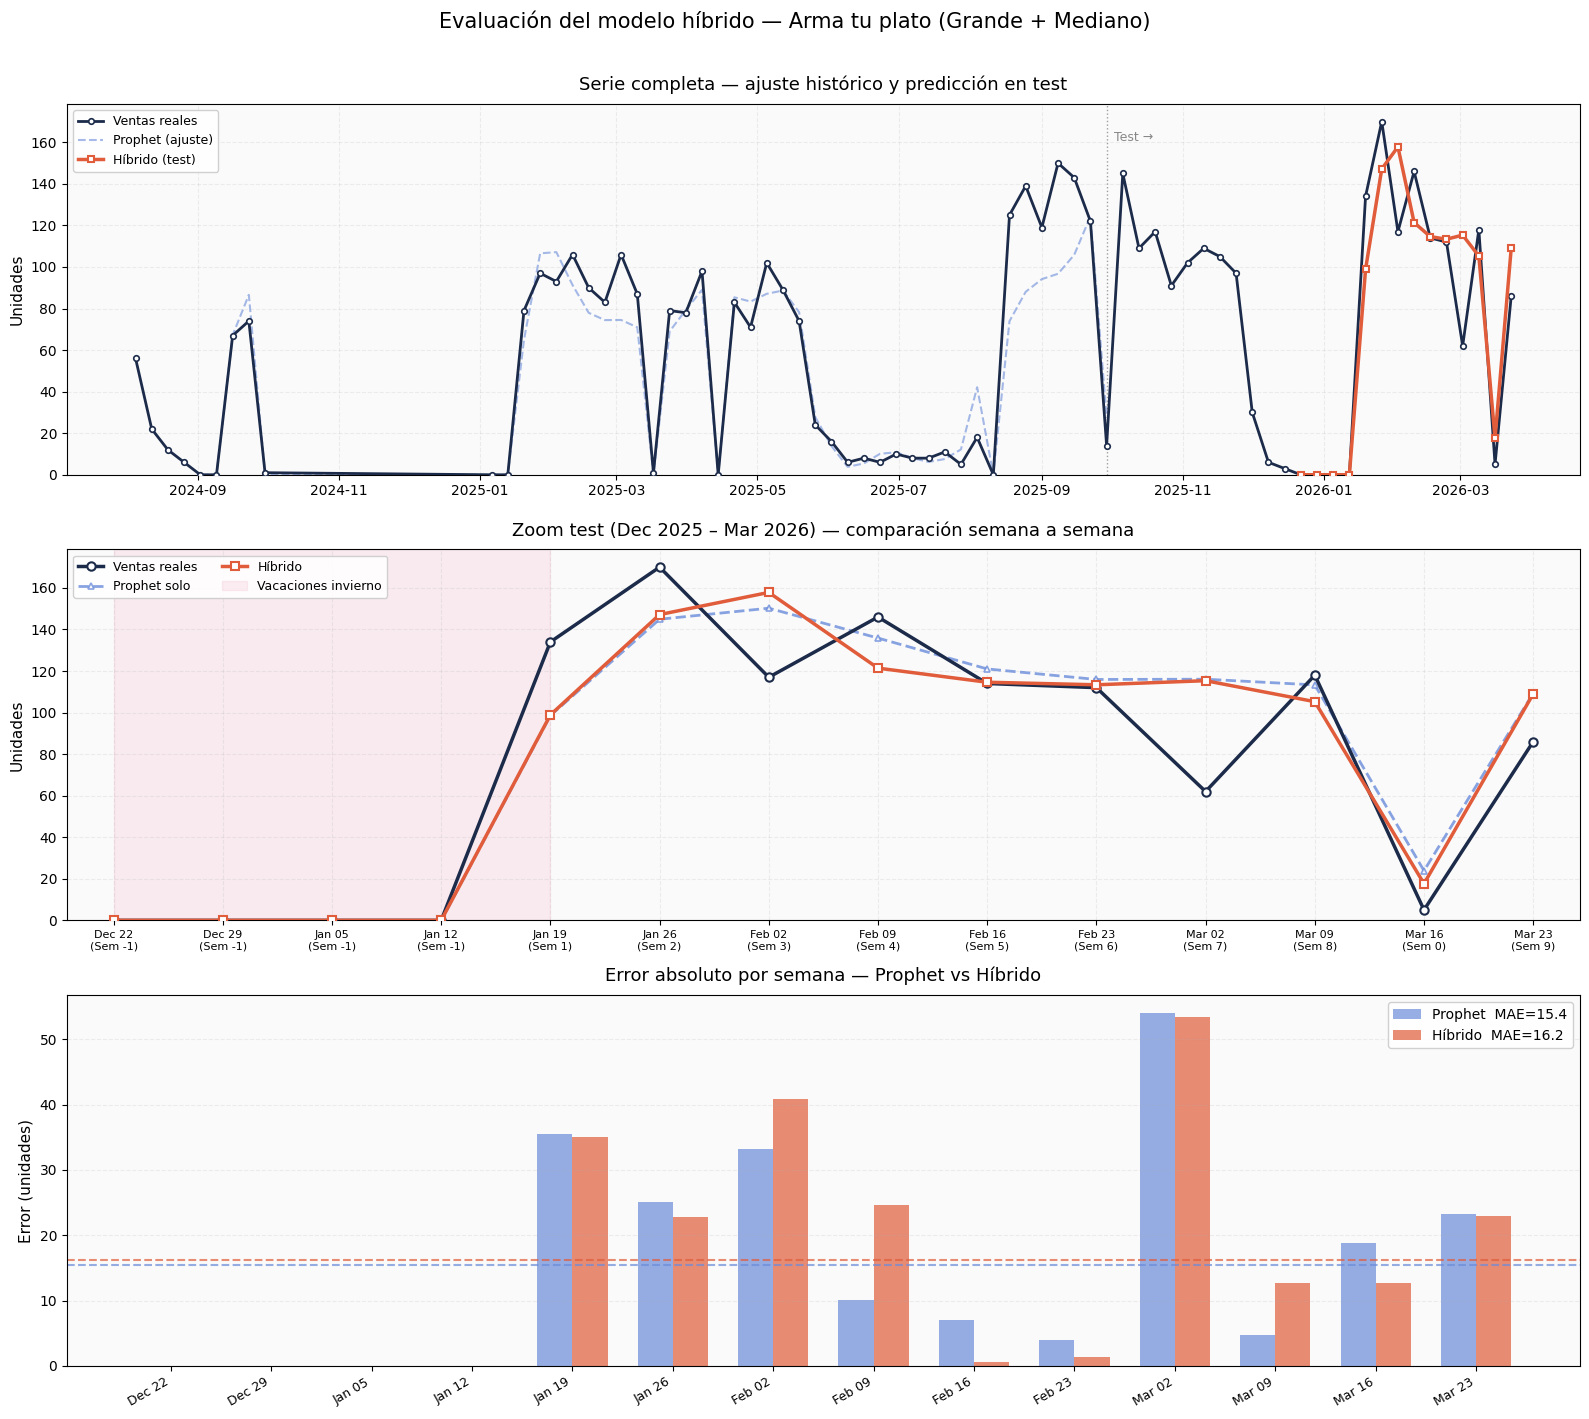

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=False)

# ── Colores ────────────────────────────────────────────────────────
COLOR_REAL    = '#1C2B4A'
COLOR_PROPHET = '#6B8CDA'
COLOR_HIBRIDO = '#E05C3A'
COLOR_BANDA   = '#E05C3A'

# ── Rango dinámico del test ────────────────────────────────────────
fecha_ini_test = test_h['ds'].min()
fecha_fin_test = test_h['ds'].max()
label_rango    = f"{fecha_ini_test.strftime('%b %Y')} – {fecha_fin_test.strftime('%b %Y')}"

# ── Periodos especiales a sombrear (solo si caen dentro del test) ──
periodos = [
    ('Exámenes dic',        pd.Timestamp('2025-12-01'), pd.Timestamp('2025-12-20'), '#5AAED4'),
    ('Vacaciones invierno', pd.Timestamp('2025-12-22'), pd.Timestamp('2026-01-19'), '#ED93B1'),
    ('Semana Santa',        pd.Timestamp('2026-03-29'), pd.Timestamp('2026-04-05'), '#F4C97A'),
]

# ══════════════════════════════════════════════════════════════════
# Panel 1 — Serie completa
# ══════════════════════════════════════════════════════════════════
ax1 = axes[0]

ax1.plot(serie_combinada['ds'], serie_combinada['y'],
         color=COLOR_REAL, linewidth=2, marker='o', markersize=4,
         markerfacecolor='white', markeredgecolor=COLOR_REAL,
         markeredgewidth=1.2, zorder=4, label='Ventas reales')

ax1.plot(train_h['ds'], train_h['yhat'].clip(0),
         color=COLOR_PROPHET, linewidth=1.5, linestyle='--',
         alpha=0.6, zorder=2, label='Prophet (ajuste)')

ax1.plot(test_h['ds'], pred_hibrida,
         color=COLOR_HIBRIDO, linewidth=2.5,
         marker='s', markersize=5,
         markerfacecolor='white', markeredgecolor=COLOR_HIBRIDO,
         markeredgewidth=1.5, zorder=4, label='Híbrido (test)')



ax1.axvline(train_h['ds'].max(), color='#888888', linewidth=1, linestyle=':', alpha=0.8)
ax1.text(train_h['ds'].max() + pd.Timedelta(days=3),
         ax1.get_ylim()[1] * 0.9, 'Test →', fontsize=9, color='#888888')

ax1.set_title('Serie completa — ajuste histórico y predicción en test',
              fontsize=13, pad=10)
ax1.set_ylabel('Unidades', fontsize=11)
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.set_facecolor('#FAFAFA')
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)

# ══════════════════════════════════════════════════════════════════
# Panel 2 — Zoom en periodo de test
# ══════════════════════════════════════════════════════════════════
ax2 = axes[1]

ax2.plot(test_h['ds'], y_test_real.values,
         color=COLOR_REAL, linewidth=2.5, marker='o', markersize=6,
         markerfacecolor='white', markeredgecolor=COLOR_REAL,
         markeredgewidth=1.5, zorder=4, label='Ventas reales')

ax2.plot(test_h['ds'], test_h['yhat'].clip(0),
         color=COLOR_PROPHET, linewidth=2, linestyle='--',
         marker='^', markersize=5,
         markerfacecolor='white', markeredgecolor=COLOR_PROPHET,
         markeredgewidth=1.2, alpha=0.8, zorder=3, label='Prophet solo')

ax2.plot(test_h['ds'], pred_hibrida,
         color=COLOR_HIBRIDO, linewidth=2.5,
         marker='s', markersize=6,
         markerfacecolor='white', markeredgecolor=COLOR_HIBRIDO,
         markeredgewidth=1.5, zorder=4, label='Híbrido')



# --- NUEVA LÓGICA DE ETIQUETAS ---
# Forzamos los ticks a las fechas exactas de test_h
ax2.set_xticks(test_h['ds'])

# Creamos las etiquetas combinadas
etiquetas_zoom = [f"{d.strftime('%b %d')}\n(Sem {s})" 
                  for d, s in zip(test_h['ds'], test_h['semana_academica'])]

ax2.set_xticklabels(etiquetas_zoom, fontsize=8, rotation=0, ha='center')
# --------------------------------

# Sombrear solo los periodos que caen dentro del rango del test
for nombre, inicio, fin, color in periodos:
    if inicio <= fecha_fin_test and fin >= fecha_ini_test:
        ax2.axvspan(max(inicio, fecha_ini_test), min(fin, fecha_fin_test),
                    color=color, alpha=0.15, label=nombre)

ax2.set_xlim(fecha_ini_test - pd.Timedelta(days=3),
             fecha_fin_test + pd.Timedelta(days=3))

ax2.set_title(f'Zoom test ({label_rango}) — comparación semana a semana',
              fontsize=13, pad=10)
ax2.set_ylabel('Unidades', fontsize=11)
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.set_facecolor('#FAFAFA')
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=2)

# ══════════════════════════════════════════════════════════════════
# Panel 3 — Error absoluto semana a semana
# ══════════════════════════════════════════════════════════════════
ax3 = axes[2]

error_prophet = abs(y_test_real.values - test_h['yhat'].clip(0).values)
error_hibrido = abs(y_test_real.values - pred_hibrida)

x     = np.arange(len(test_h))
ancho = 0.35

ax3.bar(x - ancho/2, error_prophet, ancho,
        color=COLOR_PROPHET, alpha=0.7, label=f'Prophet  MAE={error_prophet.mean():.1f}')
ax3.bar(x + ancho/2, error_hibrido, ancho,
        color=COLOR_HIBRIDO, alpha=0.7, label=f'Híbrido  MAE={error_hibrido.mean():.1f}')

ax3.axhline(error_prophet.mean(), color=COLOR_PROPHET, linewidth=1.5, linestyle='--', alpha=0.7)
ax3.axhline(error_hibrido.mean(), color=COLOR_HIBRIDO, linewidth=1.5, linestyle='--', alpha=0.7)

ax3.set_xticks(x)
ax3.set_xticklabels([d.strftime('%b %d') for d in test_h['ds']],
                    rotation=30, ha='right', fontsize=9)
ax3.set_title('Error absoluto por semana — Prophet vs Híbrido',
              fontsize=13, pad=10)
ax3.set_ylabel('Error (unidades)', fontsize=11)
ax3.grid(True, alpha=0.2, linestyle='--', axis='y')
ax3.set_facecolor('#FAFAFA')
ax3.legend(fontsize=10, framealpha=0.9)

# ══════════════════════════════════════════════════════════════════
fig.suptitle('Evaluación del modelo híbrido — Arma tu plato (Grande + Mediano)',
             fontsize=15, fontweight='500', y=1.01)
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


### Feature importance

¿Qué variables corrigen más a Prophet? Se usa la métrica **gain** de XGBoost: indica cuánto mejora la predicción en promedio cada feature cuando se usa para hacer un split.

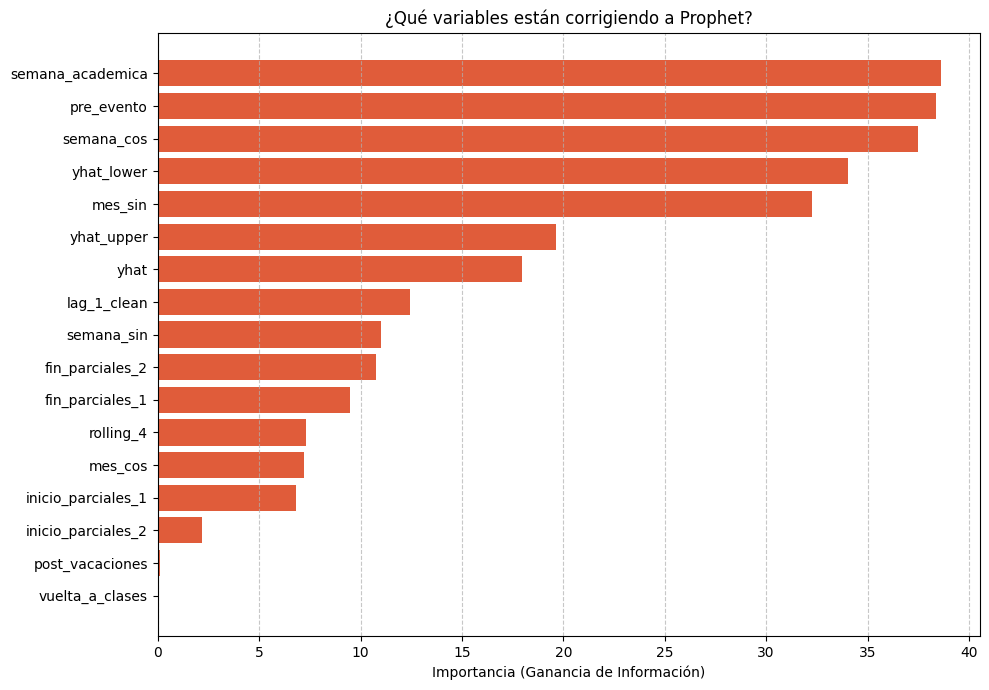

In [47]:
# Entrenar modelo sobre train_h para extraer importancias
modelo_xgb_final = XGBRegressor(**best_params)
modelo_xgb_final.fit(train_h[FEATURES_HIBRIDO], train_h['residuo'])

importancias = modelo_xgb_final.get_booster().get_score(importance_type='gain')
df_importancia = (
    pd.DataFrame({'Feature': list(importancias.keys()), 'Importancia (Gain)': list(importancias.values())})
    .sort_values(by='Importancia (Gain)', ascending=True)
)

plt.figure(figsize=(10, 7))
plt.barh(df_importancia['Feature'], df_importancia['Importancia (Gain)'], color='#E05C3A')
plt.xlabel('Importancia (Ganancia de Información)')
plt.title('¿Qué variables están corrigiendo a Prophet?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


---

## Análisis de Autocorrelación (ACF / PACF)

Se analiza si los residuos del modelo híbrido contienen estructura no capturada:

- **ACF** (*Autocorrelation Function*): mide correlación del residuo con sus propios rezagos. Picos significativos indican que el error no es ruido blanco — hay información predecible que el modelo está dejando pasar.
- **PACF** (*Partial ACF*): muestra la correlación directa de cada rezago eliminando el efecto de los intermedios. Útil para diagnosticar qué lag específico agregar.
- **Test de Ljung-Box**: hipótesis nula = residuos son ruido blanco. Si p-value < 0.05 → hay autocorrelación en los errores → el modelo se puede mejorar.

También se analiza el ACF/PACF de la **serie original** para entender la estructura de dependencia temporal de las ventas.

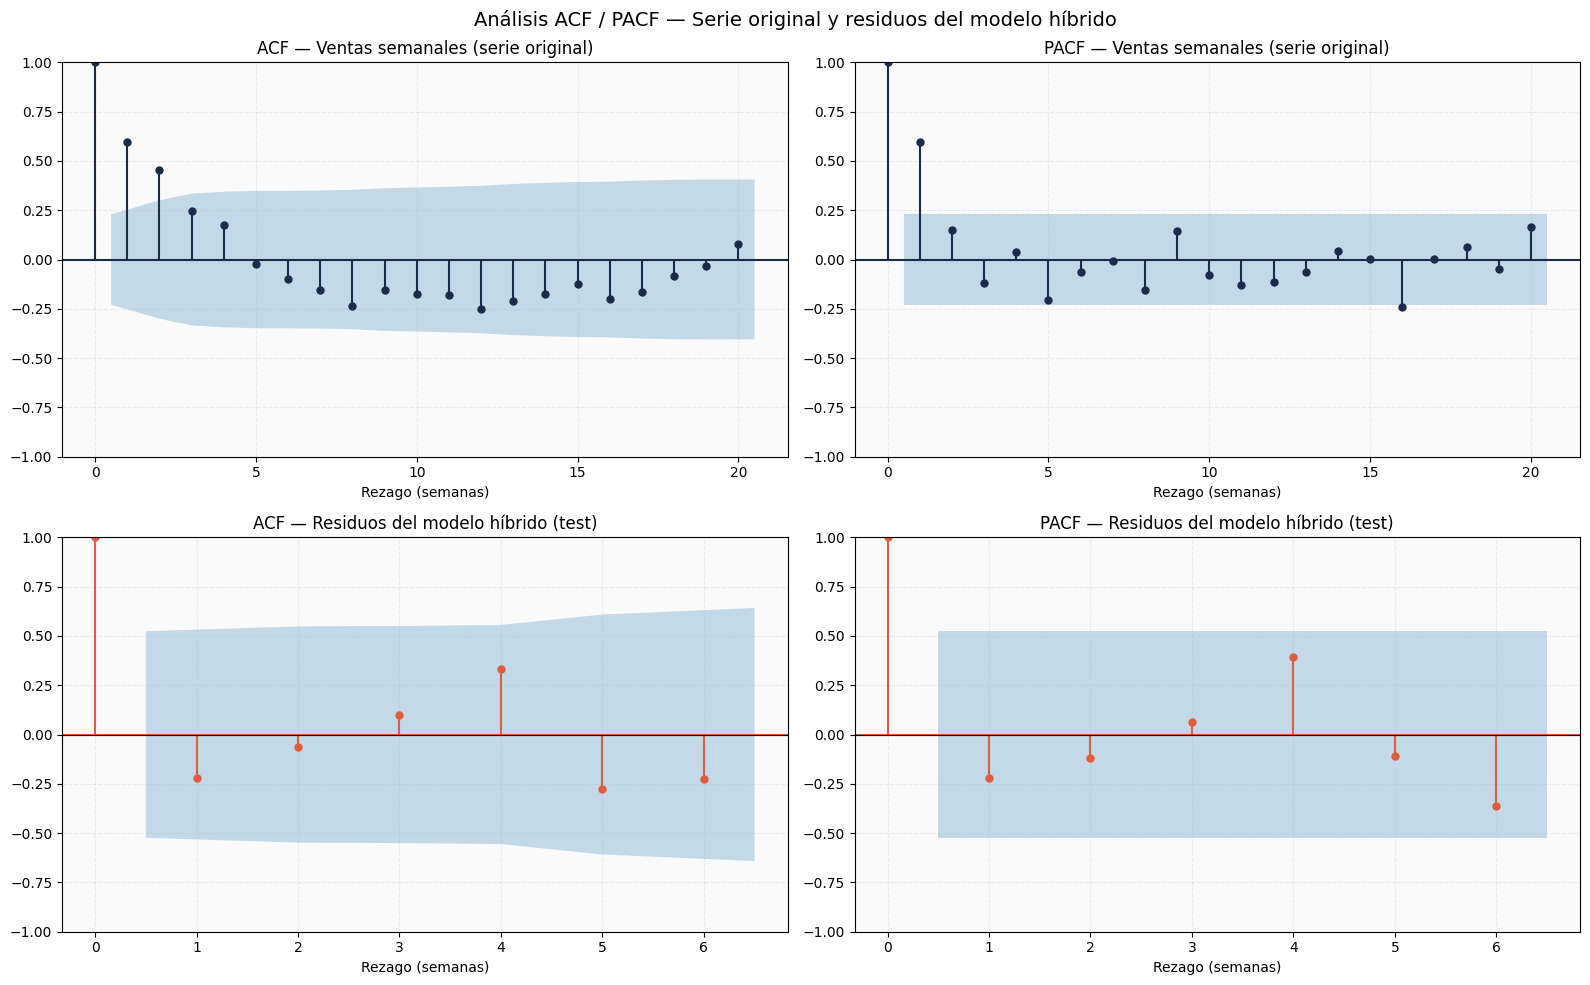

TEST DE LJUNG-BOX — Residuos del modelo híbrido
H0: los residuos son ruido blanco (sin autocorrelación)
Rechazar H0 si p-value < 0.05
     estadístico   p-value      conclusión
lag                                       
1       0.823588  0.364133  ✅ Ruido blanco
2       0.903964  0.636366  ✅ Ruido blanco
3       1.113591  0.773794  ✅ Ruido blanco
4       3.624422  0.459214  ✅ Ruido blanco
5       5.513266  0.356493  ✅ Ruido blanco
6       6.927589  0.327596  ✅ Ruido blanco
Resumen: 0/6 lags con autocorrelación significativa (p < 0.05)
→ Los residuos no muestran autocorrelación. El modelo captura bien la estructura temporal.


In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

# ── Residuos del modelo híbrido (serie completa de entrenamiento + test) ────
# Usamos los residuos del test set; si quieres más puntos, usa los de Prophet CV
residuos = (y_test_real.values - pred_hibrida).astype(float)
serie_y  = serie_combinada.set_index("ds")["y"].astype(float)

lags_max = min(15, len(residuos) // 2 - 1)  # máximo de lags válidos para la muestra

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Análisis ACF / PACF — Serie original y residuos del modelo híbrido",
             fontsize=14, fontweight="500")

# ── Panel 1: ACF de la serie original ───────────────────────────────────────
plot_acf(serie_y.dropna(), lags=20, alpha=0.05, ax=axes[0, 0],
         color="#1C2B4A", vlines_kwargs={"colors": "#1C2B4A"})
axes[0, 0].set_title("ACF — Ventas semanales (serie original)", fontsize=12)
axes[0, 0].set_xlabel("Rezago (semanas)")
axes[0, 0].set_facecolor("#FAFAFA")
axes[0, 0].grid(True, alpha=0.2, linestyle="--")

# ── Panel 2: PACF de la serie original ──────────────────────────────────────
plot_pacf(serie_y.dropna(), lags=20, alpha=0.05, method="ywm", ax=axes[0, 1],
          color="#1C2B4A", vlines_kwargs={"colors": "#1C2B4A"})
axes[0, 1].set_title("PACF — Ventas semanales (serie original)", fontsize=12)
axes[0, 1].set_xlabel("Rezago (semanas)")
axes[0, 1].set_facecolor("#FAFAFA")
axes[0, 1].grid(True, alpha=0.2, linestyle="--")

# ── Panel 3: ACF de residuos del híbrido ────────────────────────────────────
plot_acf(residuos, lags=lags_max, alpha=0.05, ax=axes[1, 0],
         color="#E05C3A", vlines_kwargs={"colors": "#E05C3A"})
axes[1, 0].set_title("ACF — Residuos del modelo híbrido (test)", fontsize=12)
axes[1, 0].set_xlabel("Rezago (semanas)")
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].set_facecolor("#FAFAFA")
axes[1, 0].grid(True, alpha=0.2, linestyle="--")

# ── Panel 4: PACF de residuos del híbrido ───────────────────────────────────
plot_pacf(residuos, lags=lags_max, alpha=0.05, method="ywm", ax=axes[1, 1],
          color="#E05C3A", vlines_kwargs={"colors": "#E05C3A"})
axes[1, 1].set_title("PACF — Residuos del modelo híbrido (test)", fontsize=12)
axes[1, 1].set_xlabel("Rezago (semanas)")
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_facecolor("#FAFAFA")
axes[1, 1].grid(True, alpha=0.2, linestyle="--")

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

# ── Test de Ljung-Box sobre residuos ────────────────────────────────────────
print("\
" + "="*55)
print("TEST DE LJUNG-BOX — Residuos del modelo híbrido")
print("="*55)
print("H0: los residuos son ruido blanco (sin autocorrelación)")
print("Rechazar H0 si p-value < 0.05\
")

lb = acorr_ljungbox(residuos, lags=list(range(1, lags_max + 1)), return_df=True)
lb.index.name = "lag"
lb.columns = ["estadístico", "p-value"]
lb["conclusión"] = lb["p-value"].apply(
    lambda p: "❌ Autocorrelación detectada" if p < 0.05 else "✅ Ruido blanco"
)
print(lb.to_string())

# Resumen ejecutivo
n_sig = (lb["p-value"] < 0.05).sum()
print(f"\
Resumen: {n_sig}/{lags_max} lags con autocorrelación significativa (p < 0.05)")
if n_sig > 0:
    lags_sig = lb[lb["p-value"] < 0.05].index.tolist()
    print(f"Lags significativos: {lags_sig}")
    print("→ Considerar agregar estos lags como features en XGBoost.")
else:
    print("→ Los residuos no muestran autocorrelación. El modelo captura bien la estructura temporal.")


---

## 8. Pipeline final — todos los productos Clase A

Se aplica el mismo pipeline al conjunto completo de **productos Clase A**:
1. Serie limpia (sin cierre oct-dic 2024)
2. Split 80/20
3. Optuna → mejores hiperparámetros de Prophet
4. Prophet entrenado sobre serie completa → genera `yhat` base
5. Optuna + TimeSeriesSplit → mejores hiperparámetros de XGBoost
6. XGBoost entrenado para corregir residuos de Prophet
7. Métricas en test: Prophet vs Híbrido

In [ ]:
ventas_p


In [57]:
import time
import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
optuna.logging.set_verbosity(optuna.logging.WARNING)

smape = lambda y, yhat: (2 * abs(y - yhat) / (abs(y) + abs(yhat) + 1e-8)).mean()

FEATURES_HIBRIDO = [
    'yhat', 'yhat_lower', 'yhat_upper',
    'semana_academica', 'pre_evento',
    'inicio_parciales_1', 'fin_parciales_1',
    'inicio_parciales_2', 'fin_parciales_2',
    'mes_sin', 'mes_cos', 'semana_sin', 'semana_cos',
    'lag_1_clean', 'rolling_4', 'vuelta_a_clases', 'post_vacaciones'
]

# Productos a modelar: Clase A (nombres ya limpios por limpiar_nombre_final en ventas_p)
productos_a_modelar = productos_clase_a["Nombre"].tolist()

resultados         = []
predicciones_guardadas = {}
start = time.time()

for producto in productos_a_modelar:
    t0 = time.time()
    print(f"\n── {producto} ──")

    # ── 1. Serie semanal ──────────────────────────────────────────
    serie = preparar_serie_semanal(dataset_p, producto)
    
    # ── 2. Excluir cierre oct-dic 2024 ───────────────────────────
    serie = serie[
        ~((serie['ds'].dt.year == 2024) &
          (serie['ds'].dt.month.isin([10, 11, 12])))
    ].reset_index(drop=True)

    # ── 3. Prophet (parámetros fijos del prototipo) ───────────────
    modelo_p, forecast = entrenar_prophet(serie)

    indices_cero = serie[serie['y'] == 0].index
    forecast.loc[forecast.index.isin(indices_cero), 'yhat']       = 0
    forecast.loc[forecast.index.isin(indices_cero), 'yhat_lower'] = 0
    forecast.loc[forecast.index.isin(indices_cero), 'yhat_upper'] = 0

    forecast_hist = forecast[forecast['ds'].isin(serie['ds'])][
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ].copy()

    # ── 4. Residuos + features ────────────────────────────────────
    df_h = serie.merge(forecast_hist, on='ds', how='left')
    df_h['residuo'] = df_h['y'] - df_h['yhat']

    df_h_feat = crear_features(df_h[['ds', 'y']], vacaciones)
    df_h_feat = df_h_feat.merge(
        df_h[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'residuo']],
        on='ds', how='left'
    )

    df_modelo_h = df_h_feat.dropna(subset=FEATURES_HIBRIDO).copy()
    n          = len(df_modelo_h)
    corte_val  = int(0.65 * n)
    corte_test = int(0.80 * n)

    # ── 5. Optuna: hiperparámetros XGBoost (walk-forward val) ─────
    def objective(trial):
        params = dict(
            n_estimators     = trial.suggest_int('n_estimators', 100, 600),
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.25, log=True),
            max_depth        = trial.suggest_int('max_depth', 2, 7),
            subsample        = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 15),
            reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 2.0),
            reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 5.0),
            random_state=42, n_jobs=-1
        )
        errores = []
        for i in range(corte_val, corte_test):
            train_wf = df_modelo_h.iloc[:i]
            sig_sem  = df_modelo_h.iloc[[i]]
            m = XGBRegressor(**params)
            m.fit(train_wf[FEATURES_HIBRIDO], train_wf['residuo'])
            pred = (sig_sem['yhat'].values + m.predict(sig_sem[FEATURES_HIBRIDO])).clip(0)
            errores.append(mean_absolute_error(sig_sem['y'].values, pred))
        return float(np.mean(errores))

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=50, show_progress_bar=False)
    best_params = study.best_params
    best_params.update({'random_state': 42, 'n_jobs': -1})

    # ── 6. Evaluación walk-forward en test ────────────────────────
    errores_test      = []
    reales_test       = []
    predicciones_test = []
    test_slice        = df_modelo_h.iloc[corte_test:]

    for i in range(corte_test, n):
        train_wf = df_modelo_h.iloc[:i]
        sig_sem  = df_modelo_h.iloc[[i]]
        m = XGBRegressor(**best_params)
        m.fit(train_wf[FEATURES_HIBRIDO], train_wf['residuo'])
        pred_residuo = m.predict(sig_sem[FEATURES_HIBRIDO])
        pred_final   = (sig_sem['yhat'].values + pred_residuo).clip(0)
        errores_test.append(mean_absolute_error(sig_sem['y'].values, pred_final))
        reales_test.append(sig_sem['y'].values[0])
        predicciones_test.append(pred_final[0])

    reales_test       = np.array(reales_test)
    predicciones_test = np.array(predicciones_test)
    # Forzar 0 cuando Prophet ya predice 0 (vacaciones/cierre)
    predicciones_test = np.where(test_slice['yhat'].values == 0, 0, predicciones_test)

    mae_hibrido = mean_absolute_error(reales_test, predicciones_test)
    mae_prophet = mean_absolute_error(reales_test, test_slice['yhat'].clip(0).values)

    # ── 7. Predicción próxima semana ─────────────────────────────
    modelo_final = XGBRegressor(**best_params)
    modelo_final.fit(df_modelo_h[FEATURES_HIBRIDO], df_modelo_h['residuo'])

    proxima_fecha = serie['ds'].max() + pd.Timedelta(weeks=1)

    # Extender serie con placeholder para construir features de la semana futura
    serie_ext   = pd.concat(
        [serie, pd.DataFrame({'ds': [proxima_fecha], 'y': [0.0]})],
        ignore_index=True
    )
    feat_futuro = crear_features(serie_ext, vacaciones).iloc[[-1]].copy()
    forecast_prox = forecast[forecast['ds'] == proxima_fecha][
        ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
    ]
    feat_futuro = feat_futuro.merge(forecast_prox, on='ds', how='left')

    if feat_futuro[FEATURES_HIBRIDO].notna().all(axis=None):
        corr      = modelo_final.predict(feat_futuro[FEATURES_HIBRIDO])
        pred_prox = int(np.ceil(max(0.0, feat_futuro['yhat'].values[0] + corr[0])))
    else:
        pred_prox = int(np.ceil(max(0.0, forecast_prox['yhat'].values[0])))

    dur = time.time() - t0
    print(f"  MAE Prophet  : {mae_prophet:.1f}")
    print(f"  MAE Híbrido  : {mae_hibrido:.1f}  (mejora: {mae_prophet - mae_hibrido:+.1f})")
    print(f"  Pred {proxima_fecha.date()} : {pred_prox} unidades  [{dur:.0f}s]")

    resultados.append({
        "Producto":     producto,
        "N_semanas":    len(serie),
        "MAE_Hibrido":  mae_hibrido,
        "MAE_Prophet":  mae_prophet,
        "Mejora":       mae_prophet - mae_hibrido,
        "Pred_proxima": pred_prox,
        "Fecha_pred":   proxima_fecha.date(),
    })
    predicciones_guardadas[producto] = {
        "historial_test": pd.DataFrame({
            "ds":         test_slice['ds'].values,
            "real":       reales_test,
            "prediccion": predicciones_test,
            "prophet":    test_slice['yhat'].values,
        }),
        "mae_test_walkforward":      mae_hibrido,
        "mae_test_prophet_solo":     mae_prophet,
        "mejora_mae":                mae_prophet - mae_hibrido,
        "prediccion_proxima_semana": pred_prox,
        "fecha_proxima_semana":      proxima_fecha,
    }

df_resumen = pd.DataFrame(resultados).sort_values("MAE_Hibrido").reset_index(drop=True)
print(f"\nTiempo total: {(time.time()-start)/60:.1f} min")
print("── Resumen final ──────────────────────────────────────────────")
print(df_resumen.to_string(index=False))




── Arma tu plato ──


18:04:03 - cmdstanpy - INFO - Chain [1] start processing
18:04:05 - cmdstanpy - INFO - Chain [1] done processing


  MAE Prophet  : 18.3
  MAE Híbrido  : 18.1  (mejora: +0.1)
  Pred 2026-03-30 : 46 unidades  [97s]

── Bowl pollo tostada ──


18:05:40 - cmdstanpy - INFO - Chain [1] start processing
18:05:41 - cmdstanpy - INFO - Chain [1] done processing


  MAE Prophet  : 7.5
  MAE Híbrido  : 6.4  (mejora: +1.1)
  Pred 2026-03-30 : 10 unidades  [112s]

── Ensalada chefsito ──


...

  MAE Prophet  : 4.1
  MAE Híbrido  : 4.2  (mejora: -0.0)
  Pred 2026-03-30 : 5 unidades  [127s]

── Sándwich criollo ──


18:16:48 - cmdstanpy - INFO - Chain [1] start processing
18:16:49 - cmdstanpy - INFO - Chain [1] done processing


  MAE Prophet  : 3.1
  MAE Híbrido  : 2.4  (mejora: +0.7)
  Pred 2026-03-30 : 9 unidades  [100s]

── Ensalada pollo pesto ──


18:18:28 - cmdstanpy - INFO - Chain [1] start processing
18:18:29 - cmdstanpy - INFO - Chain [1] done processing


  MAE Prophet  : 2.8
  MAE Híbrido  : 4.1  (mejora: -1.3)
  Pred 2026-03-30 : 7 unidades  [128s]

Tiempo total: 16.5 min
── Resumen final ──────────────────────────────────────────────
                   Producto  N_semanas  MAE_Hibrido  MAE_Prophet    Mejora  Pred_proxima Fecha_pred
           Sándwich criollo         73     2.353155     3.071429  0.718273             9 2026-03-30
       Ensalada pollo pesto         73     4.114921     2.785714 -1.329207             7 2026-03-30
             Bowl lomo alto         73     4.156946     3.928571 -0.228374             6 2026-03-30
Ensalada pollo miel mostaza         73     4.187086     4.142857 -0.044229             5 2026-03-30
          Bowl colombianito         73     4.748038     4.714286 -0.033752             4 2026-03-30
           Bowl pasta buona         73     5.502238     6.928571  1.426333            10 2026-03-30
         Bowl pollo tostada         73     6.438353     7.500000  1.061647            10 2026-03-30
            Sán

### Comparación de modelos por producto

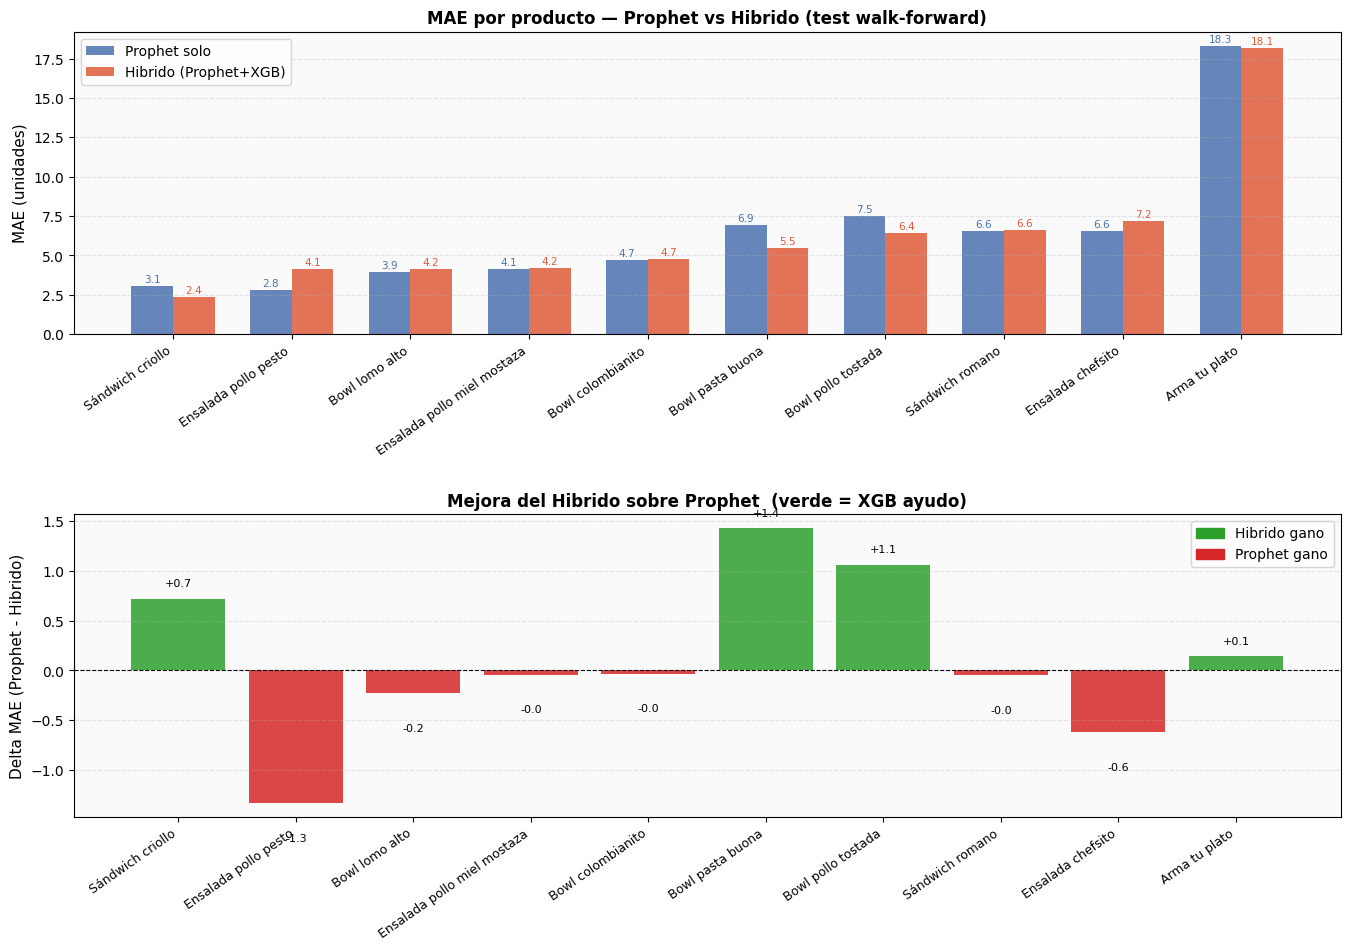

Guardado: comparacion_modelos_actualizada.png


In [58]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor("white")

productos_plot = df_resumen["Producto"].tolist()
x = np.arange(len(productos_plot))
w = 0.35

# ── 1. MAE por producto — Prophet vs Hibrido ──────────────────────
ax = axes[0]
bars_p = ax.bar(x - w/2, df_resumen["MAE_Prophet"], w,
                label="Prophet solo", color="#4C72B0", alpha=0.85)
bars_h = ax.bar(x + w/2, df_resumen["MAE_Hibrido"], w,
                label="Hibrido (Prophet+XGB)", color="#E05C3A", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(productos_plot, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("MAE (unidades)", fontsize=11)
ax.set_title("MAE por producto — Prophet vs Hibrido (test walk-forward)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_facecolor("#FAFAFA")
for bar in bars_p:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.1f}", ha="center", va="bottom",
            fontsize=7.5, color="#4C72B0")
for bar in bars_h:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.1f}", ha="center", va="bottom",
            fontsize=7.5, color="#E05C3A")

# ── 2. Mejora del hibrido (MAE_Prophet - MAE_Hibrido) ────────────
ax2 = axes[1]
colores = ["#2CA02C" if v > 0 else "#D62728" for v in df_resumen["Mejora"]]
bars = ax2.bar(x, df_resumen["Mejora"], color=colores, alpha=0.85)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_xticks(x)
ax2.set_xticklabels(productos_plot, rotation=35, ha="right", fontsize=9)
ax2.set_ylabel("Delta MAE (Prophet - Hibrido)", fontsize=11)
ax2.set_title("Mejora del Hibrido sobre Prophet  (verde = XGB ayudo)",
              fontsize=12, fontweight="bold")
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax2.set_facecolor("#FAFAFA")
for bar, val in zip(bars, df_resumen["Mejora"]):
    offset = 0.1 if val >= 0 else -0.4
    ax2.text(bar.get_x() + bar.get_width()/2, val + offset,
             f"{val:+.1f}", ha="center", va="bottom", fontsize=8)
patch_win  = mpatches.Patch(color="#2CA02C", label="Hibrido gano")
patch_lose = mpatches.Patch(color="#D62728", label="Prophet gano")
ax2.legend(handles=[patch_win, patch_lose], fontsize=10)

plt.tight_layout(pad=2.5)
plt.savefig("comparacion_modelos_actualizada.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: comparacion_modelos_actualizada.png")


### Visualización por producto

Usar `graficar_producto(nombre)` para ver la serie completa, el ajuste de Prophet y la predicción híbrida para cualquier producto del Clase A.

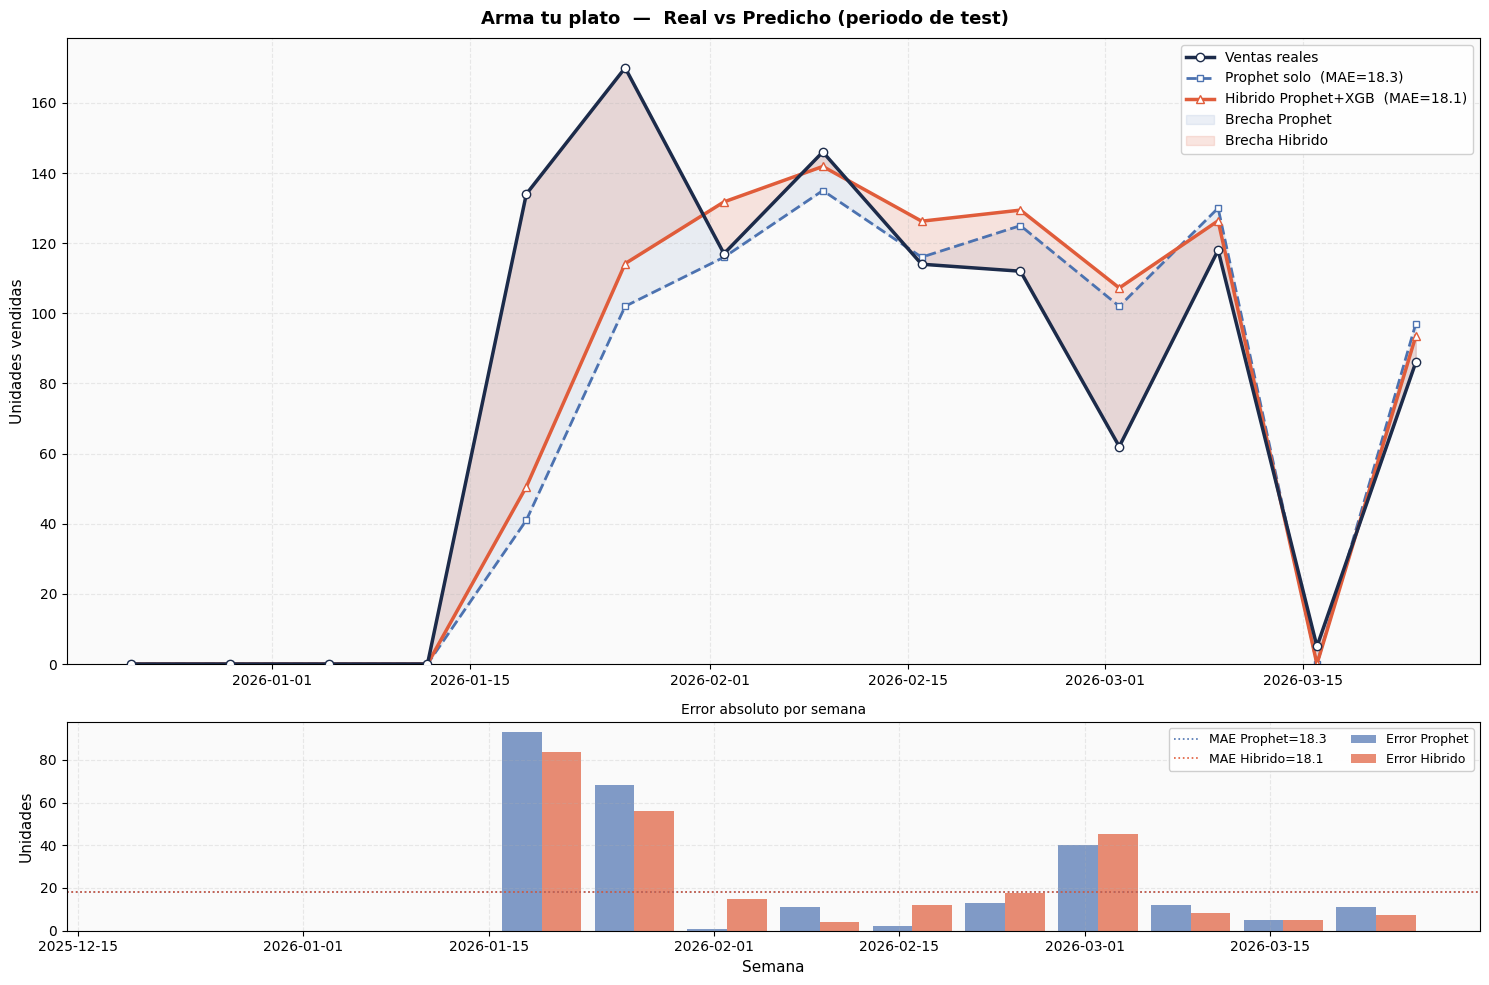

MAE Hibrido: 18.14  |  MAE Prophet: 18.29  |  Mejora: +0.15


In [60]:
from sklearn.metrics import mean_absolute_error

def graficar_producto(producto):
    """Grafica real vs predicho (hibrido) y vs prophet solo en el periodo de test."""
    if producto not in predicciones_guardadas:
        print(f"'{producto}' no encontrado. Disponibles:")
        print(list(predicciones_guardadas.keys()))
        return

    d = predicciones_guardadas[producto]
    hist = d["historial_test"].copy()  # columnas: ds, real, prediccion, prophet
    hist["ds"] = pd.to_datetime(hist["ds"])

    mae_h = mean_absolute_error(hist["real"], hist["prediccion"])
    mae_p = mean_absolute_error(hist["real"], hist["prophet"])

    fig, axes = plt.subplots(2, 1, figsize=(15, 10),
                             gridspec_kw={"height_ratios": [3, 1]})
    fig.patch.set_facecolor("white")
    fig.suptitle(f"{producto}  —  Real vs Predicho (periodo de test)",
                 fontsize=13, fontweight="bold")

    # ── Panel 1: real vs prophet vs hibrido ──────────────────────
    ax = axes[0]
    ax.plot(hist["ds"], hist["real"],
            color="#1C2B4A", linewidth=2.5, marker="o", markersize=6,
            markerfacecolor="white", markeredgecolor="#1C2B4A",
            label="Ventas reales", zorder=4)
    ax.plot(hist["ds"], hist["prophet"],
            color="#4C72B0", linewidth=2, linestyle="--", marker="s", markersize=5,
            markerfacecolor="white", label=f"Prophet solo  (MAE={mae_p:.1f})")
    ax.plot(hist["ds"], hist["prediccion"],
            color="#E05C3A", linewidth=2.5, marker="^", markersize=6,
            markerfacecolor="white", label=f"Hibrido Prophet+XGB  (MAE={mae_h:.1f})")

    # Sombrear brechas
    ax.fill_between(hist["ds"], hist["real"], hist["prophet"],
                    alpha=0.10, color="#4C72B0", label="Brecha Prophet")
    ax.fill_between(hist["ds"], hist["real"], hist["prediccion"],
                    alpha=0.15, color="#E05C3A", label="Brecha Hibrido")

    ax.set_ylabel("Unidades vendidas", fontsize=11)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.set_facecolor("#FAFAFA")
    ax.legend(fontsize=10, framealpha=0.9)

    # ── Panel 2: error absoluto por semana ───────────────────────
    ax2 = axes[1]
    error_h = (hist["real"] - hist["prediccion"]).abs()
    error_p = (hist["real"] - hist["prophet"]).abs()
    ancho = 3  # dias
    ax2.bar(hist["ds"] - pd.Timedelta(days=ancho/2), error_p, ancho,
            color="#4C72B0", alpha=0.7, label="Error Prophet")
    ax2.bar(hist["ds"] + pd.Timedelta(days=ancho/2), error_h, ancho,
            color="#E05C3A", alpha=0.7, label="Error Hibrido")
    ax2.axhline(mae_p, color="#4C72B0", linestyle=":", linewidth=1.2,
                label=f"MAE Prophet={mae_p:.1f}")
    ax2.axhline(mae_h, color="#E05C3A", linestyle=":", linewidth=1.2,
                label=f"MAE Hibrido={mae_h:.1f}")
    ax2.set_title("Error absoluto por semana", fontsize=10)
    ax2.set_ylabel("Unidades", fontsize=11)
    ax2.set_xlabel("Semana", fontsize=11)
    ax2.set_ylim(bottom=0)
    ax2.grid(True, alpha=0.25, linestyle="--")
    ax2.set_facecolor("#FAFAFA")
    ax2.legend(fontsize=9, ncol=2, framealpha=0.95)

    plt.tight_layout()
    nombre_archivo = producto.replace(" ", "_").replace("/", "-")
    plt.savefig(f"pred_{nombre_archivo}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"MAE Hibrido: {mae_h:.2f}  |  MAE Prophet: {mae_p:.2f}  |  Mejora: {mae_p - mae_h:+.2f}")


# ── USO: llama con cualquier producto del top-10 ─────────────────
graficar_producto("Arma tu plato")
